Este Notebook tem como objetivo realizar uma análise exploratória sobre os dados das ocorrências de trânsito ocorridas em rodovias federais. Os dados foram coletados pela polícia rodoviária federal. Neste estudo, foram utilizados os dados entre 2020 e 2026


In [90]:
# RAW DATASET

# a PRF disponibiliza os arquivos .csv ano a ano, dessa forma a primeira tarefa foi aglutinar todos os anos analisados em um único .csv
# o csv bruto disponibilizado no GitHub já é o que contém os dados de 2020 até 2026


# download do dataset no Dia 19/08/2026 do link https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf
# data inicio do dataset: 01/01/2020
# data final do dataset: 31/07/2026
# após filtragem, foi detectado que os registros do estado do RS estavam contabilizados somente até junho/2026


A serra gaúcha não é uma divisão que oficializa quais munícipios fazem parte, o recorte costuma variar de acordo com os critérios utilizados, como culturais, financeiros e geográficos. Para esse estudo, consideramos como Serra Gaúcha os 32 municípios participantes do Conselho Regional de Desenvolvimento da Serra, junto de outros 7 municípios que costumeiramente são classificados como Serra gaúcha. Totalizando então, 39 municípios.

A célula abaixo tem o intuito de representar por código a filtragem realizado no dataset. Na prática, a filtragem foi feita manualmente pelo Excel, utilizando como critério as cidades selecionadas.

Outra mudança realizada no csv, foi em uma coluna que não achamos clara o suficiente. Se trata da coluna 'uso_solo', sempre atribuída 'sim' ou 'não'. Analisando o dicionário de dados da PRF, esse atributo representa se a ocorrência foi em área urbana (sim), ou área rural (não). Sendo assim, a coluna foi renomeada para área_urbana manualmente no Excel. A simulação dessa alteração, em código, está na etapa 4 da célula abaixo, vale ressaltar que os valores de 'sim' e 'não' permaneceram inalterados

In [130]:
# 1. Lista global de municípios da Serra Gaúcha
LISTA_MUNICIPIOS = [
    'Caxias do Sul', 'Bento Gonçalves', 'Farroupilha', 'Garibaldi', 'Antônio Prado',
    'Boa Vista do Sul', 'Carlos Barbosa', 'Gramado', 'Canela', 'Nova Prata', 'Barão',
    'São Pedro da Serra', 'Picada Café', 'Morro Reuter', 'Veranópolis', 'Flores da Cunha',
    'Nova Petrópolis', 'Coronel Pilar', 'Cotiporã', 'Fagundes Varela', 'Guabiju',
    'Guaporé', 'Montauri', 'Monte Belo do Sul', 'Nova Araçá', 'Nova Bassano',
    'Nova Pádua', 'Nova Roma do Sul', 'Paraí', 'Pinto Bandeira', 'Protásio Alves',
    'Santa Tereza', 'São Jorge', 'São Marcos', 'São Valentim do Sul', 'Serafina Corrêa',
    'União da Serra', 'Vila Flores', 'Vista Alegre do Prata'
]


# 2. Carregar o dataset original completo
# df_br = pd.read_csv('Dados_Rodovia_Bruto.csv', encoding='latin1', sep=None, engine='python')

# 3. Filtrar as entradas cuja cidade pertence ao conjunto da Serra Gaúcha
# df_serra_gaucha = df_br[df_br['municipio'].isin(LISTA_MUNICIPIOS)].copy()

# 4. Exemplo de tratamento automatizado
# df['area_urbana'] = df['uso_solo'].map({'sim': 'sim', 'não': 'não'})
# lista_upper = [m.upper() for m in LISTA_MUNICIPIOS]
# df_serra = df[df['municipio'].isin(lista_upper)].copy()

# 5. Salvar o dataset filtrado resultante
# df_serra_gaucha.to_file if hasattr(df_serra_gaucha, 'to_file') else df_serra_gaucha.to_csv('Dados_Rodovia.csv', index=False)

In [131]:
#importações de bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*Found unknown categories.*")

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [132]:
import pandas as pd
from google.colab import files

# opção para fazer upload do arquivo na execução
uploaded = files.upload()


df = pd.read_csv('Dados_Rodovia.csv', sep=';', encoding='latin1')

# identificação dos atributos
print(df.head())
# verificação de valores nulos
print(df.isna().sum())

Saving Dados_Rodovia.csv to Dados_Rodovia (3).csv
       id data_inversa    dia_semana   horario  uf   br     km  \
0  260749   04/01/2020        sábado  07:00:00  RS  470    156   
1  263303   17/01/2020   sexta-feira  07:00:00  RS  470    227   
2  264219   21/01/2020   terça-feira  12:25:00  RS  470  194,8   
3  264232   21/01/2020   terça-feira  14:25:00  RS  116    153   
4  264556   23/01/2020  quinta-feira  06:55:00  RS  470  218,9   

         municipio               causa_acidente              tipo_acidente  \
0       NOVA PRATA      Velocidade Incompatível            Colisão lateral   
1        GARIBALDI  Falta de Atenção à Condução  Saída de leito carroçável   
2  BENTO GONCALVES      Velocidade Incompatível            Colisão frontal   
3    CAXIAS DO SUL  Defeito Mecânico no Veículo           Colisão traseira   
4  BENTO GONCALVES  Falta de Atenção à Condução            Colisão frontal   

   ... feridos_graves ilesos ignorados feridos veiculos      latitude  \
0  ...     

In [133]:
#Verificar se há valores nulos
df.info()
#Descrição da quantidade de dados não nulos por atributo e seu tipo
df.describe()
#Verificar quantas vezes cada município apareceu ao longo do dataset
df['municipio'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3346 entries, 0 to 3345
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      3346 non-null   int64 
 1   data_inversa            3346 non-null   object
 2   dia_semana              3346 non-null   object
 3   horario                 3346 non-null   object
 4   uf                      3346 non-null   object
 5   br                      3346 non-null   int64 
 6   km                      3346 non-null   object
 7   municipio               3346 non-null   object
 8   causa_acidente          3346 non-null   object
 9   tipo_acidente           3346 non-null   object
 10  classificacao_acidente  3346 non-null   object
 11  fase_dia                3346 non-null   object
 12  sentido_via             3346 non-null   object
 13  condicao_metereologica  3346 non-null   object
 14  tipo_pista              3346 non-null   object
 15  trac

,count
municipio,
CAXIAS DO SUL,1155
BENTO GONCALVES,664
GARIBALDI,337
VERANOPOLIS,255
SAO MARCOS,203
NOVA PRATA,195
PICADA CAFE,126
CARLOS BARBOSA,124
BARAO,74


In [134]:
# corrigindo formato da data
df['data_inversa'] = pd.to_datetime(df['data_inversa'], format='%d/%m/%Y')
df['ano'] = df['data_inversa'].dt.year

ocorrencias_por_ano = df['ano'].value_counts().sort_index()

print("Ocorrências por Ano:")
print(ocorrencias_por_ano)

Ocorrências por Ano:
ano
2020    481
2021    507
2022    538
2023    514
2024    568
2025    523
2026    215
Name: count, dtype: int64


# Gráfico de Ocorrências por ano

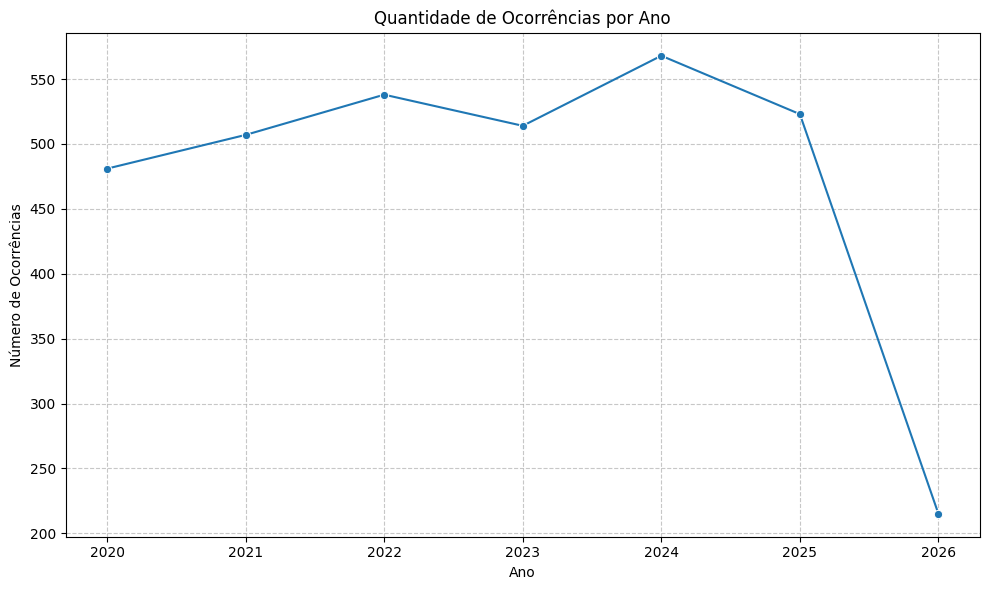

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=ocorrencias_por_ano.index, y=ocorrencias_por_ano.values, marker='o')
plt.title('Quantidade de Ocorrências por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Ocorrências')
plt.xticks(ocorrencias_por_ano.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [136]:
# numero total de ocorrencias no dataset bruto: 439.903 (TODAS AS CIDADES DO BRASIL)

ocorrencias_total = len(df)

# cálculo da média de acidentes por ano, excluindo 2026 por possuir dados somente até junho/2026
media_acidentes_anual_sem_2026 = ocorrencias_por_ano[ocorrencias_por_ano.index != 2026].mean()

print("Total de ocorrências no dataset bruto: 439.903 (TODAS AS CIDADES DO BRASIL)")
print(f"Total de ocorrências na Serra Gaúcha: {ocorrencias_total}")
print(f"Média de acidentes anual (excluindo 2026): {media_acidentes_anual_sem_2026:.2f}")

Total de ocorrências no dataset bruto: 439.903 (TODAS AS CIDADES DO BRASIL)
Total de ocorrências na Serra Gaúcha: 3346
Média de acidentes anual (excluindo 2026): 521.83


# Gráfico de ocorrências por mês

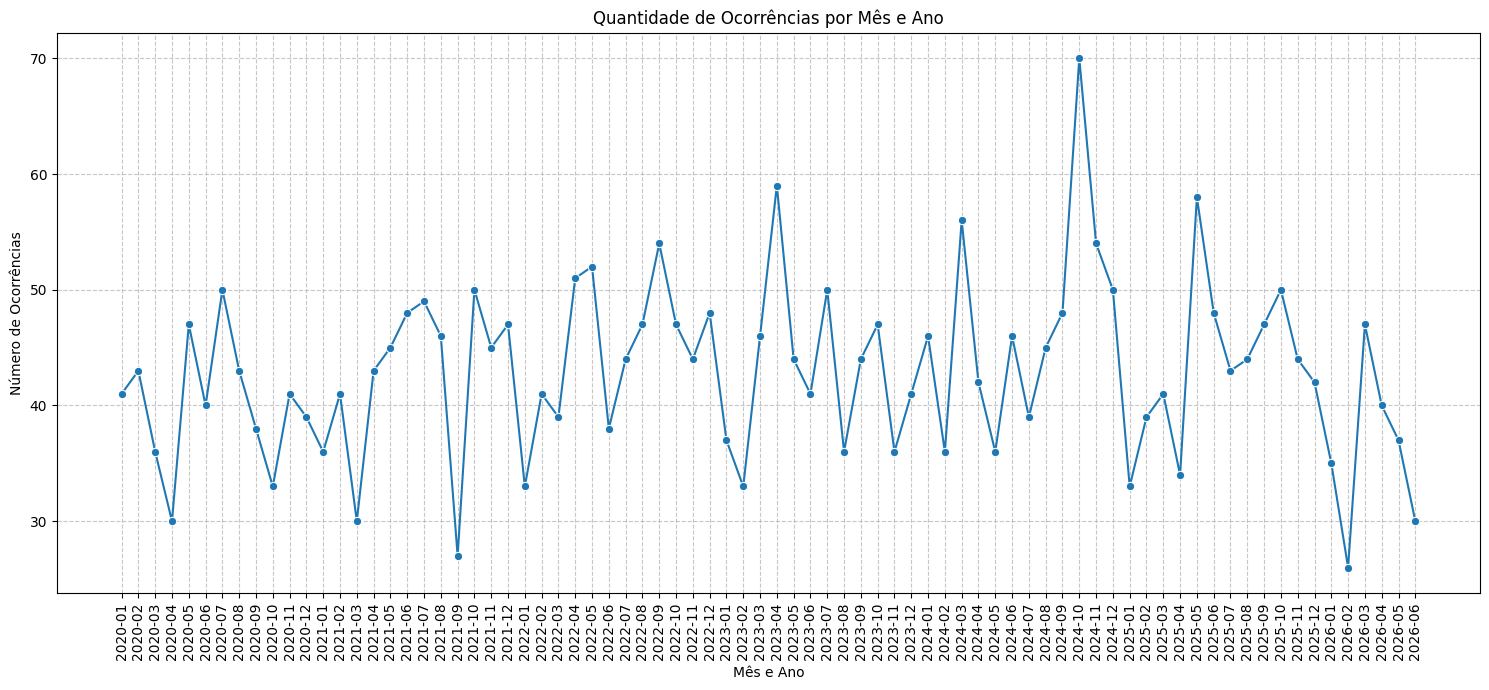

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

df['ano_mes'] = df['data_inversa'].dt.to_period('M')

ocorrencias_por_mes_ano = df['ano_mes'].value_counts().sort_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x=ocorrencias_por_mes_ano.index.astype(str), y=ocorrencias_por_mes_ano.values, marker='o')
plt.title('Quantidade de Ocorrências por Mês e Ano')
plt.xlabel('Mês e Ano')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=90, ha='center')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [138]:
# Extrair o mês da coluna 'data_inversa'
df['mes'] = df['data_inversa'].dt.month

# Agrupar por ano e mês para obter a contagem de ocorrências por cada mês específico (ex: Jan/2020, Fev/2020)
ocorrencias_por_ano_mes = df.groupby([df['data_inversa'].dt.year, df['mes']]).size().reset_index(name='contagem')

# Renomear as colunas para clareza
ocorrencias_por_ano_mes.columns = ['ano', 'mes', 'contagem']

# Filtrar dados para excluir o ano de 2026 na média mensal, pois está incompleto
ocorrencias_por_ano_mes_filtrado = ocorrencias_por_ano_mes[ocorrencias_por_ano_mes['ano'] != 2026]

# Calcular a média de ocorrências para cada mês (considerando os anos completos)
media_ocorrencias_por_mes = ocorrencias_por_ano_mes_filtrado.groupby('mes')['contagem'].mean().reset_index()
media_ocorrencias_por_mes.columns = ['mes', 'media_acidentes']

# Mapear números do mês para nomes para melhor visualização
nome_meses = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
    7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}
media_ocorrencias_por_mes['nome_mes'] = media_ocorrencias_por_mes['mes'].map(nome_meses)

# Ordenar para encontrar os 5 meses com maior média de acidentes
top5_meses_maior_media = media_ocorrencias_por_mes.sort_values(by='media_acidentes', ascending=False).head(5)

print("Média de Acidentes por Mês (excluindo 2026):")
display(media_ocorrencias_por_mes.sort_values(by='mes'))

print("\nTop 5 Meses com Maior Média de Acidentes (excluindo 2026):")
display(top5_meses_maior_media)

# Calcular a média mensal global (todos os meses de todos os anos completos, dividido pelo número total de meses)

# Já temos 'ocorrencias_por_ano_mes_filtrado' que exclui 2026
total_ocorrencias_filtradas = ocorrencias_por_ano_mes_filtrado['contagem'].sum()
total_meses_unicos_contados = len(ocorrencias_por_ano_mes_filtrado)

# A média mensal global será o total de acidentes dividido pelo número de meses no período filtrado
media_mensal_global = total_ocorrencias_filtradas / total_meses_unicos_contados

print(f"\nMédia Mensal Global de Acidentes (excluindo 2026): {media_mensal_global:.2f}")

Média de Acidentes por Mês (excluindo 2026):


,mes,media_acidentes,nome_mes
0,1,37.666667,Janeiro
1,2,38.833333,Fevereiro
2,3,41.333333,Março
3,4,43.166667,Abril
4,5,47.000000,Maio
5,6,43.500000,Junho
6,7,45.833333,Julho
7,8,43.500000,Agosto
8,9,43.000000,Setembro
9,10,49.500000,Outubro



Top 5 Meses com Maior Média de Acidentes (excluindo 2026):


,mes,media_acidentes,nome_mes
9,10,49.500000,Outubro
4,5,47.000000,Maio
6,7,45.833333,Julho
11,12,44.500000,Dezembro
10,11,44.000000,Novembro



Média Mensal Global de Acidentes (excluindo 2026): 43.49


# Gráfico de Ocorrência por dia

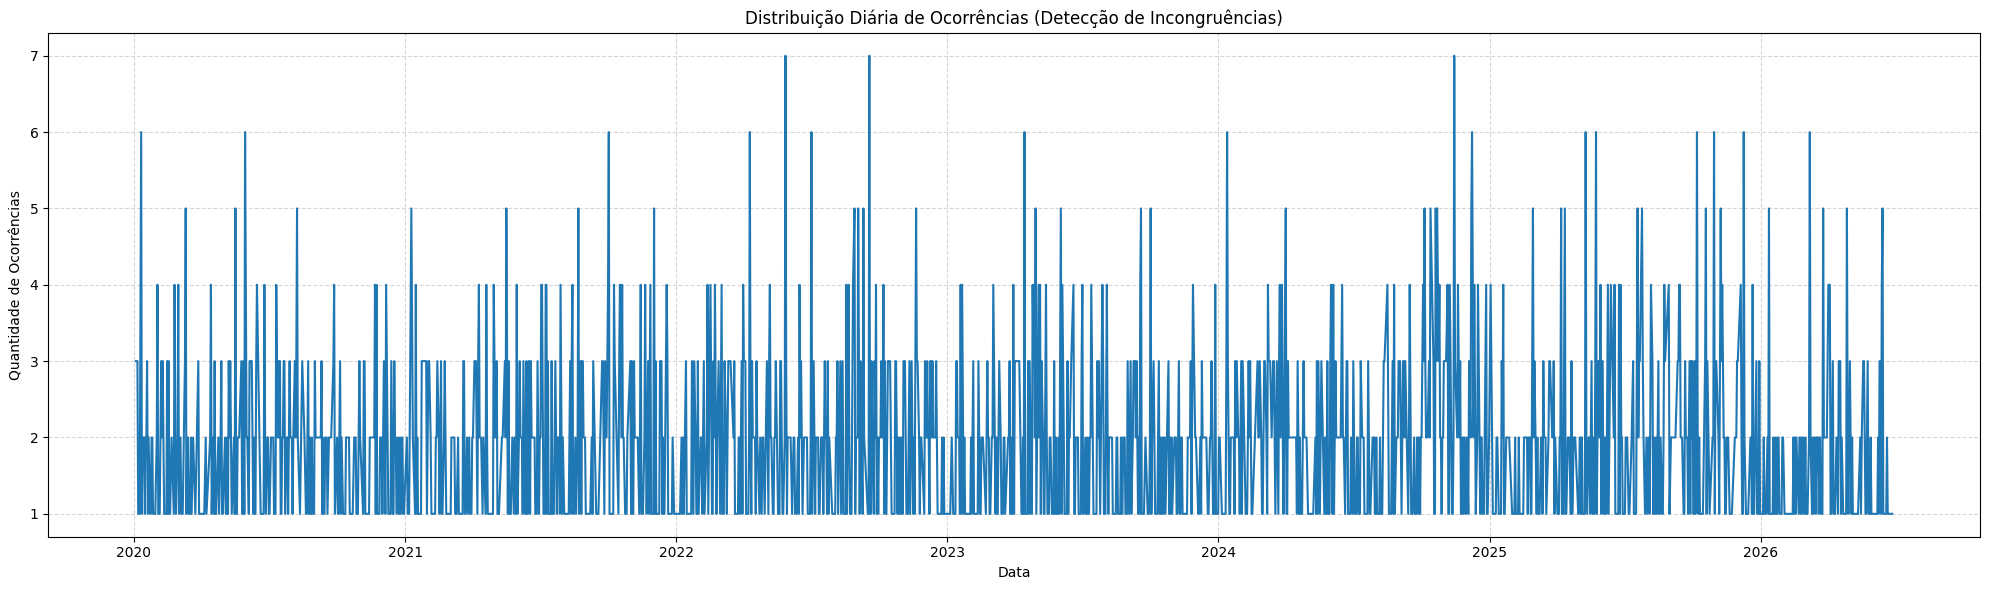

Dias com maior número de ocorrências:
data_inversa
2022-05-28    7
2022-09-18    7
2024-11-14    7
2021-10-02    6
2024-01-13    6
2022-07-02    6
2025-10-30    6
2025-12-09    6
2023-04-15    6
2025-10-07    6
Name: count, dtype: int64


In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por data exata para ver a distribuição diária
ocorrencias_por_dia = df['data_inversa'].value_counts().sort_index()

plt.figure(figsize=(20, 6))
sns.lineplot(x=ocorrencias_por_dia.index, y=ocorrencias_por_dia.values)
plt.title('Distribuição Diária de Ocorrências (Detecção de Incongruências)')
plt.xlabel('Data')
plt.ylabel('Quantidade de Ocorrências')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Mostrar os dias com maior volume para análise manual
print("Dias com maior número de ocorrências:")
print(ocorrencias_por_dia.sort_values(ascending=False).head(10))

Média de Acidentes por Dia da Semana:


,nome_dia_da_semana,contagem
3,Segunda-feira,1.866397
6,Terça-feira,1.732143
1,Quarta-feira,1.641921
2,Quinta-feira,1.789030
4,Sexta-feira,1.895753
5,Sábado,2.258741
0,Domingo,2.137405


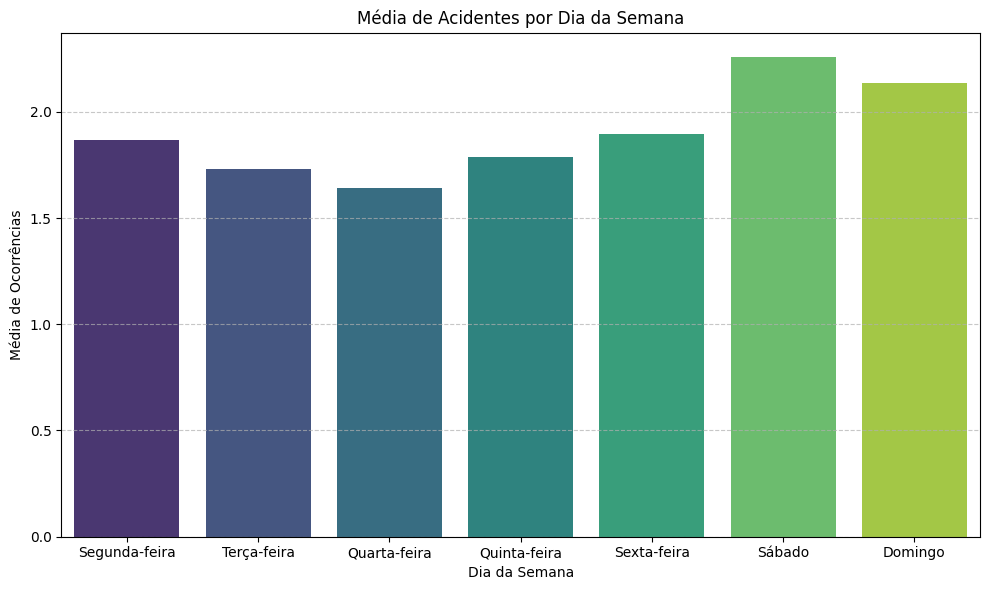


Número máximo de acidentes em um único dia: 7


In [140]:
# Extrair o dia da semana (0=segunda, 6=domingo)
df['dia_da_semana'] = df['data_inversa'].dt.dayofweek

# Mapear números do dia para nomes para melhor visualização
nome_dias_semana = {
    0: 'Segunda-feira', 1: 'Terça-feira', 2: 'Quarta-feira',
    3: 'Quinta-feira', 4: 'Sexta-feira', 5: 'Sábado', 6: 'Domingo'
}
df['nome_dia_da_semana'] = df['dia_da_semana'].map(nome_dias_semana)

# Agrupar por dia da semana e contar ocorrências, depois calcular a média
# Primeiro, contamos as ocorrências por dia exato para ter a granularidade correta
ocorrencias_por_dia_exato = df.groupby(['data_inversa', 'nome_dia_da_semana']).size().reset_index(name='contagem')

# Agora, calculamos a média de 'contagem' para cada 'nome_dia_da_semana'
media_ocorrencias_por_dia_semana = ocorrencias_por_dia_exato.groupby('nome_dia_da_semana')['contagem'].mean().reset_index()

# Ordenar pela ordem natural dos dias da semana
ordem_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
media_ocorrencias_por_dia_semana['nome_dia_da_semana'] = pd.Categorical(media_ocorrencias_por_dia_semana['nome_dia_da_semana'], categories=ordem_dias, ordered=True)
media_ocorrencias_por_dia_semana = media_ocorrencias_por_dia_semana.sort_values('nome_dia_da_semana')

print("Média de Acidentes por Dia da Semana:")
display(media_ocorrencias_por_dia_semana)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='nome_dia_da_semana', y='contagem', data=media_ocorrencias_por_dia_semana, palette='viridis')
plt.title('Média de Acidentes por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Média de Ocorrências')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Encontrar o máximo de acidentes em um único dia
max_ocorrencias_dia = ocorrencias_por_dia_exato['contagem'].max()
print(f"\nNúmero máximo de acidentes em um único dia: {max_ocorrencias_dia}")

# Quantidade de ocorrências por rodovia

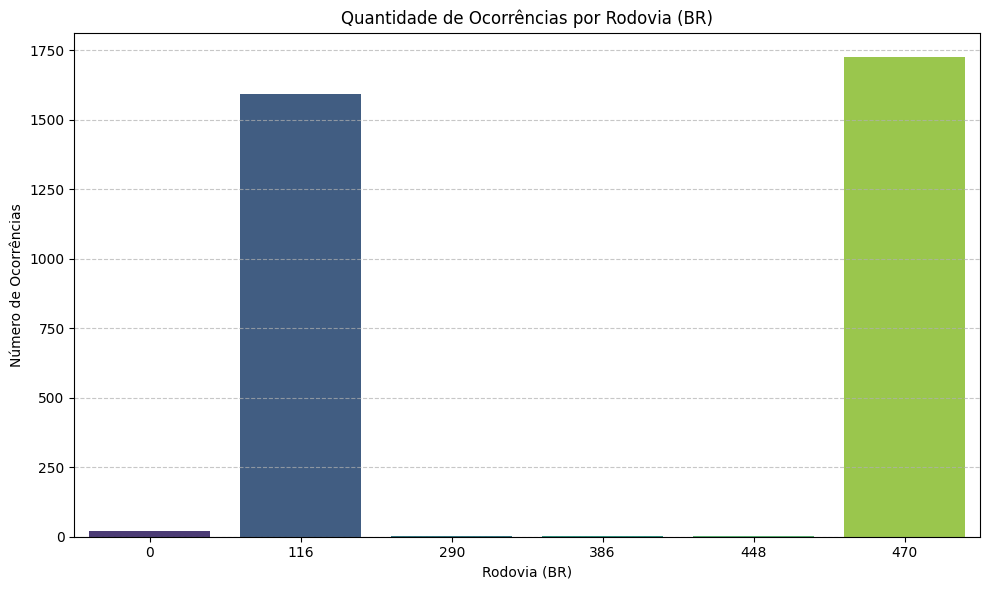

,count
br,
470,1727
116,1593
0,22
290,2
386,1
448,1


In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a contagem de ocorrências por BR
ocorrencias_br = df['br'].value_counts().sort_index()

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=ocorrencias_br.index.astype(str), y=ocorrencias_br.values, palette='viridis')

plt.title('Quantidade de Ocorrências por Rodovia (BR)')
plt.xlabel('Rodovia (BR)')
plt.ylabel('Número de Ocorrências')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
df['br'].value_counts()

In [68]:
# Foram identificadas inconsitências, pois as BRs 290, 386, 448 não estão localizadas na Serra Gaúcha (possivel erro de inserção/digitação, pois as coordenadas geogréficas
# são referentes ao municípios da Serra Gaúcha

# A BR0 pode ser interpretada como um erro ou a falta de preenchimento no momento do registro

# Optamos por remover as ocorrências nas BRs 0, 290, 386 e 448, porque o volume é muito pouco representativo para o universo de dados


In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lista das rodovias que devem ser removidas
brs_para_remover = [0, 290, 386, 448]

# 2. Filtrar o DataFrame (mantendo apenas as BRs que NÃO estão na lista de remoção)
# Nota: .astype(float) ou int garante a comparação correta independente do tipo de dado lido
df = df[~df['br'].fillna(-1).astype(int).isin(brs_para_remover)].copy()

# 3. (Opcional) Salvar a versão limpa de volta no CSV
df.to_csv('Dados_Rodovia_Filtrado.csv', index=False)


ocorrencias_total = len(df)


print("Total de ocorrências no dataset antes da limpeza: 3346")
print(f"Total de ocorrências no dataset sem as inconsistência de rodovias: {ocorrencias_total}")

Total de ocorrências no dataset antes da limpeza: 3346
Total de ocorrências no dataset sem as inconsistência de rodovias: 3320


# Distribuição de acidentes por quilometragem das rodovias

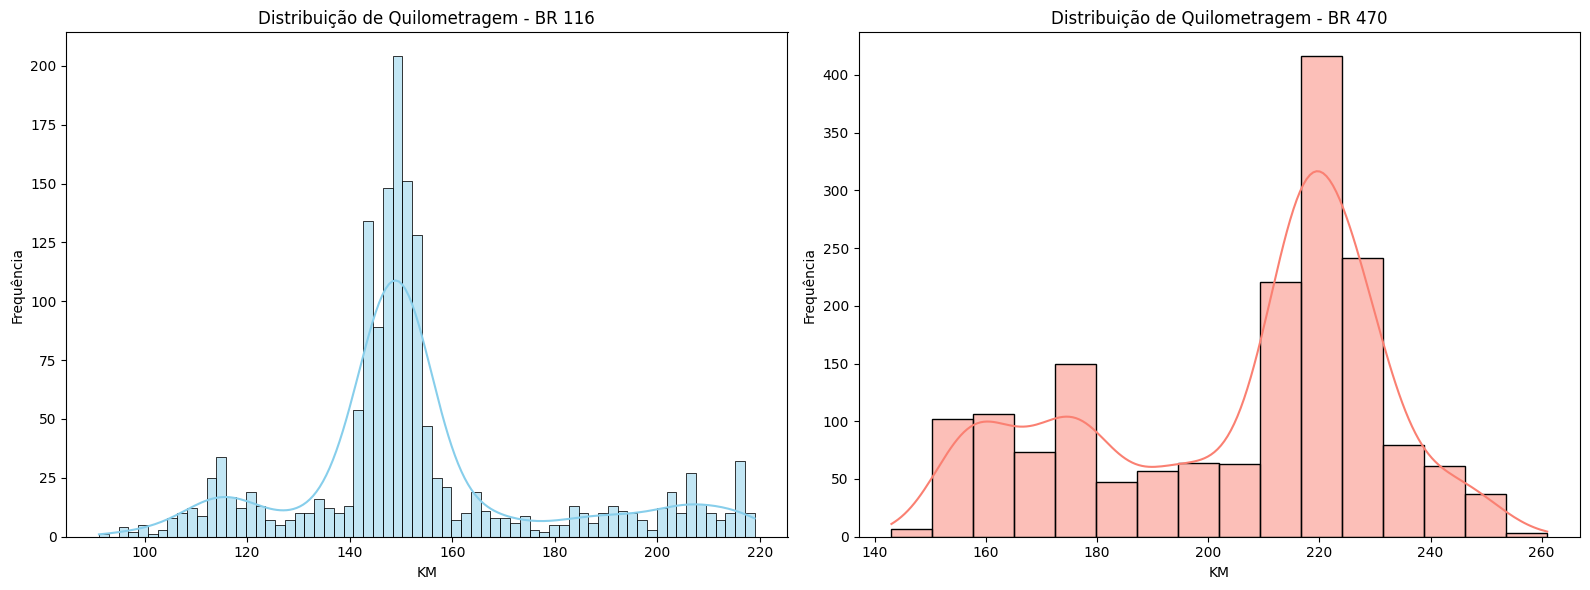

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Limpeza da coluna km (trocando vírgula por ponto e convertendo para float)
df['km'] = df['km'].str.replace(',', '.').astype(float)

# Filtrando os dados para as duas rodovias
df_116 = df[df['br'] == 116]
df_470 = df[df['br'] == 470]

# Criando a figura com dois subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para BR-116
sns.histplot(df_116['km'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Quilometragem - BR 116')
axes[0].set_xlabel('KM')
axes[0].set_ylabel('Frequência')

# Gráfico para BR-470
sns.histplot(df_470['km'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Quilometragem - BR 470')
axes[1].set_xlabel('KM')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [71]:
# maior concentração de acidentes nas quilometragens correspondentes às zonas urbanas de Caxias do Sul (BR116) e Bento Gonçalves (BR470)
# há a hipótese de que é devido ao maior volume de tráfego nessas regiões, mas é necessário um trabalho futuro para afirmar com precisão

# Traçado da Rodovia
No dataset original, pode haver uma combinação de tipos de traçado, por exemplo "curva, aclive, em obras". Para uma melhor visualização, na tabela abaixo é considerado apenas um desses tipos. Dessa forma, o acidente do exemplo anterior, conta uma ocorrência para "curva", "aclive" e "em obras". Essa metodologia foi escolhida para uma melhor visualização dos dados e diminuir uma especificidade excessiva.

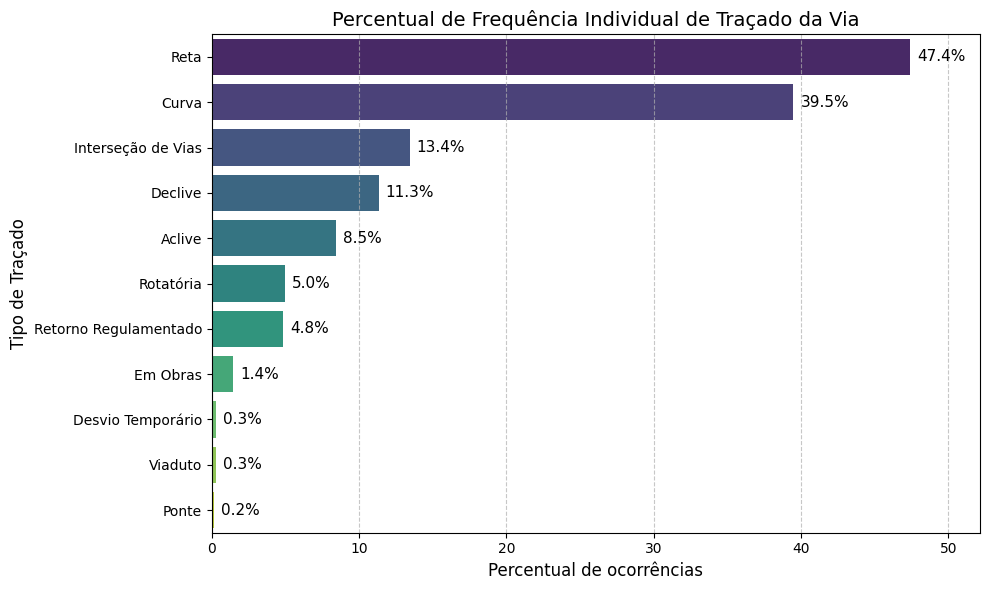

Total de marcadores individuais extraídos: 4387


,count
tracado_via,
Reta,47.409639
Curva,39.487952
Interseção de Vias,13.433735
Declive,11.325301
Aclive,8.463855
Rotatória,4.969880
Retorno Regulamentado,4.849398
Em Obras,1.445783
Desvio Temporário,0.301205


In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separar as combinações por ';' e 'explodir' em linhas individuais
tracados_isolados = (
    df['tracado_via']
    .dropna()
    .astype(str)
    .str.split(';')
    .explode()
    .str.strip()
)

# 2. Total de acidentes com informação de traçado válida
total_acidentes = df['tracado_via'].dropna().count()

# 3. Contar o percentual de cada característica de traçado
contagem_tracados_pct = (tracados_isolados.value_counts()/ total_acidentes) * 100

# 4. Criar o gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=contagem_tracados_pct.values, y=contagem_tracados_pct.index, palette='viridis')

# 5. Adicionar os valores numéricos em cima/ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, color='black',
                xytext=(5, 0), textcoords='offset points')

plt.title('Percentual de Frequência Individual de Traçado da Via', fontsize=14)
plt.xlabel('Percentual de ocorrências', fontsize=12)
plt.ylabel('Tipo de Traçado', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, contagem_tracados_pct.max() * 1.1)  # Margem para o texto não cortar
plt.tight_layout()
plt.show()

# 4. Exibir a tabela com a contagem total
print(f"Total de marcadores individuais extraídos: {len(tracados_isolados)}")
display(contagem_tracados_pct)

Para facilitar a visualização, os tipos de traçados foram agrupados em 4 caracterísiticas: reta, curva, encontro de vias (contempla interseção, rotatória, retorno e desvio) e trecho em obras

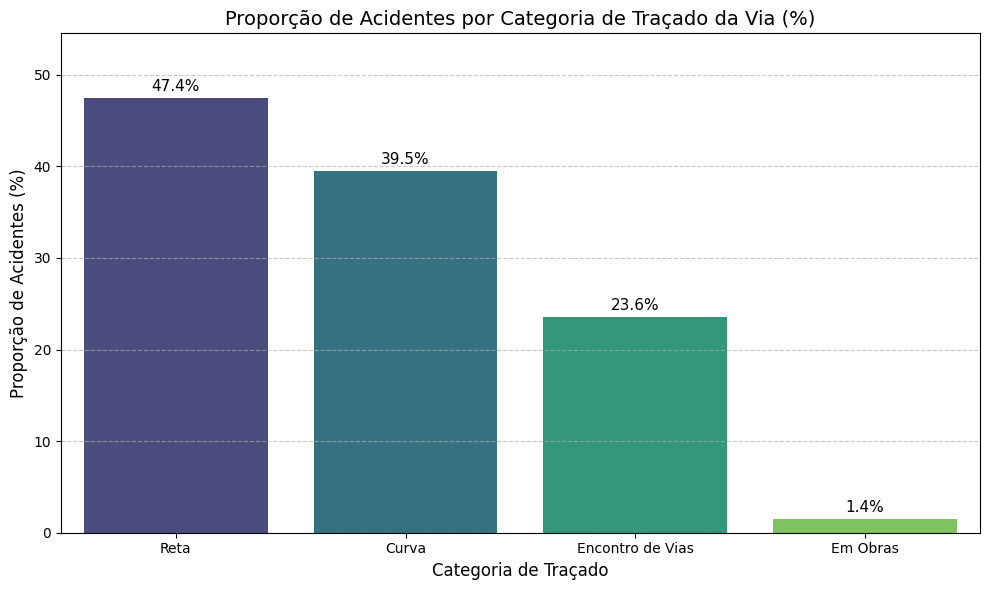

,count
tracado_via,
Reta,47.41%
Curva,39.49%
Encontro de Vias,23.55%
Em Obras,1.45%


In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separar as combinações por ';' e 'explodir' em linhas individuais
tracados_isolados = (
    df['tracado_via']
    .dropna()
    .astype(str)
    .str.split(';')
    .explode()
    .str.strip()
)

# 2. Função de agrupamento em 4 categorias principais
def agrupar_tracado(valor):
    valor_lower = valor.lower()

    if 'obras' in valor_lower:
        return 'Em Obras'
    elif any(term in valor_lower for term in ['interseção', 'intersecao', 'rotatória', 'rotatoria', 'desvio', 'retorno',]):
        return 'Encontro de Vias'
    elif 'curva' in valor_lower:
        return 'Curva'
    elif 'reta' in valor_lower:
        return 'Reta'
    else:
        return 'Outros'

# 3. Mapear os tipos de traçado para as 4 categorias
tracados_agrupados = tracados_isolados.apply(agrupar_tracado)

# Total de acidentes válidos no dataset
total_acidentes = df['tracado_via'].dropna().count()

# 4. Calcular a porcentagem de ocorrência de cada categoria
contagem_pct = (tracados_agrupados.value_counts() / total_acidentes) * 100

# Reordenar para garantir a exibição lógica das categorias
ordem_categorias = ['Reta', 'Curva', 'Encontro de Vias', 'Em Obras']
contagem_pct = contagem_pct.reindex([cat for cat in ordem_categorias if cat in contagem_pct.index])

# 5. Criar o gráfico de barras verticais
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=contagem_pct.index, y=contagem_pct.values, palette='viridis')

# Adicionar os rótulos de porcentagem acima das barras verticais
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.1f}%',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 3), textcoords='offset points')

plt.title('Proporção de Acidentes por Categoria de Traçado da Via (%)', fontsize=14)
plt.xlabel('Categoria de Traçado', fontsize=12)
plt.ylabel('Proporção de Acidentes (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, contagem_pct.max() * 1.15)  # Espaço para os rótulos no topo das barras
plt.tight_layout()
plt.show()

# 6. Exibir a tabela consolidada
display(contagem_pct.round(2).astype(str) + '%')


In [74]:
# Aqui pode-se criar a hipótese de que a maioria dos acidentes ocorrem em retas e curvas, pois, além de serem os traçados mais comuns, também são aqueles
# que permitem uma maior velocidade média para o condutor. É necessário um trabalho futuro para testar esta hipótese

# Acidentes por hora do dia

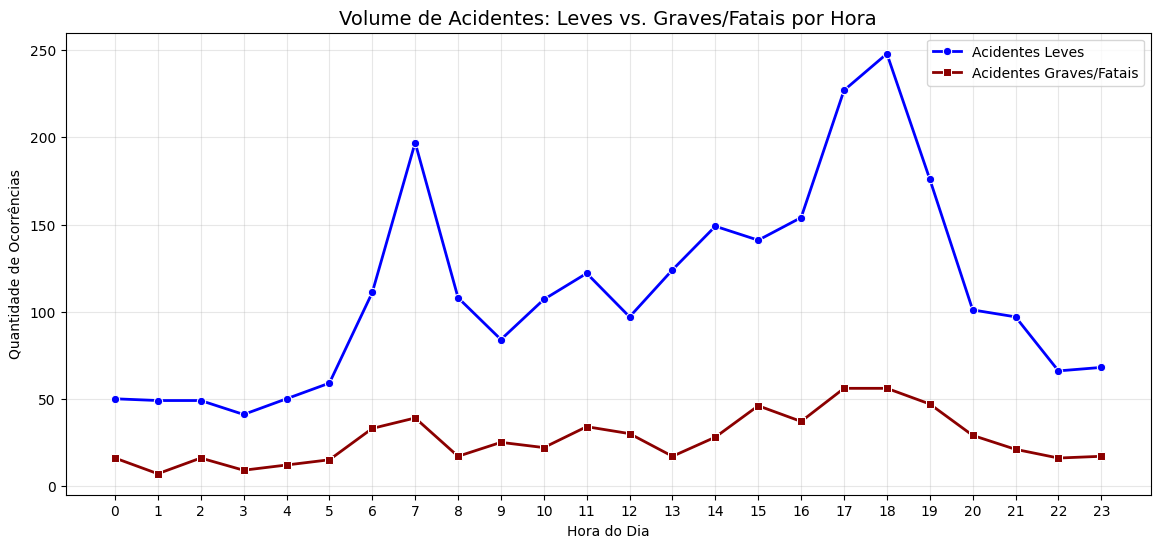

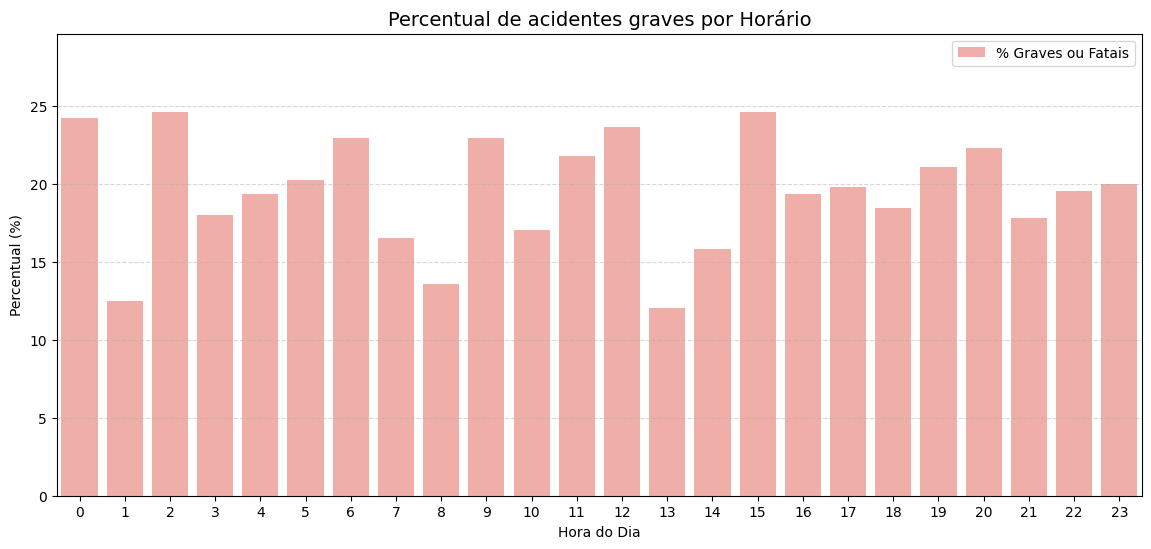

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. separação entre acidentes com vítimas graves/fatais e com vítimas leves/ilesas
df['hora_int'] = pd.to_datetime(df['horario'], format='%H:%M:%S').dt.hour
df['eh_grave'] = (df['feridos_graves'] > 0)
df['eh_fatal'] = (df['mortos'] > 0)
df['leve'] = (~df['eh_grave'] & ~df['eh_fatal'])
df['grave_ou_fatal'] = (df['eh_grave'] | df['eh_fatal'])

# 2. soma de total de acidentes por categoria
stats_hora = df.groupby('hora_int').agg(
    total_acidentes=('id', 'count'),
    total_graves=('eh_grave', 'sum'),
    total_fatais=('eh_fatal', 'sum'),
    total_criticos=('grave_ou_fatal', 'sum'),
    total_leves=('leve', 'sum')
).reset_index()

# 3. percentual de acidentes por horário
stats_hora['%_grave_fatal'] = (stats_hora['total_criticos'] / stats_hora['total_acidentes']) * 100
stats_hora['%_fatal'] = (stats_hora['total_fatais'] / stats_hora['total_acidentes']) * 100
stats_hora['%_leve'] = (stats_hora['total_leves'] / stats_hora['total_acidentes']) * 100

# 4. criação do gráfico
plt.figure(figsize=(14, 6))
sns.lineplot(x='hora_int', y='total_leves', data=stats_hora, label='Acidentes Leves', marker='o', color='blue', linewidth=2)
sns.lineplot(x='hora_int', y='total_criticos', data=stats_hora, label='Acidentes Graves/Fatais', marker='s', color='darkred', linewidth=2)

plt.title('Volume de Acidentes: Leves vs. Graves/Fatais por Hora', fontsize=14)
plt.xlabel('Hora do Dia')
plt.ylabel('Quantidade de Ocorrências')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(14, 6))
sns.barplot(x='hora_int', y='%_grave_fatal', data=stats_hora, color='salmon', alpha=0.7, label='% Graves ou Fatais')

plt.title('Percentual de acidentes graves por Horário', fontsize=14)
plt.xlabel('Hora do Dia')
plt.ylabel('Percentual (%)')
plt.xticks(range(0, 24))
plt.ylim(0, stats_hora['%_grave_fatal'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [76]:
# identificamos como hipótese que os picos de acidente ocorrem nos horários que costumam ter maior volume de tráfego, 7 horas da manhã, começo da rotina de trabalho
# e entre as 17 e 18 horas, onde muitas pessoas estão voltando do trabalho. Outra hipótese para o pico do final da tarde ser maior é que as pessoas podem já estar
# mais desgatadas mentalmente pela rotina diária e o nível de atenção esteja reduzido. Hipóteses que podem ser estudadas em trabalho futuro

# Ocorrências por condições metereológicas

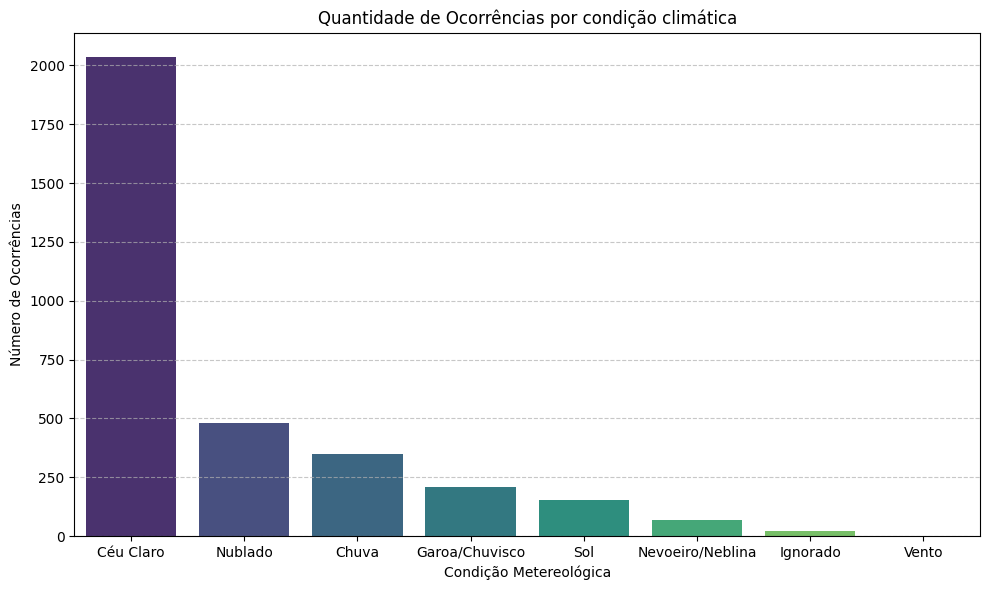

,count
condicao_metereologica,
Céu Claro,2036
Nublado,482
Chuva,351
Garoa/Chuvisco,207
Sol,155
Nevoeiro/Neblina,67
Ignorado,21
Vento,1


In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a contagem de ocorrências por BR
ocorrencias_br = df['condicao_metereologica'].value_counts()

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=ocorrencias_br.index.astype(str), y=ocorrencias_br.values, palette='viridis')

plt.title('Quantidade de Ocorrências por condição climática')
plt.xlabel('Condição Metereológica')
plt.ylabel('Número de Ocorrências')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
display(ocorrencias_br)

In [148]:
# Foram identificadas ocorrências com condição climática "indeterminada", por ser algo pouco representativo no dataset, também optamos por remover essas ocorrências

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar o DataFrame descartando as linhas com 'Ignorado'
df = df[df['condicao_metereologica'] != 'Ignorado'].copy()

# 2. Contar número de registros após a remoção
total_depois = len(df)

print("Total de ocorrências no dataset antes da limpeza: 3320")
print(f"Total de ocorrências restantes no dataset: {total_depois}")

Total de ocorrências no dataset antes da limpeza: 3320
Total de ocorrências restantes no dataset: 3299


In [ ]:
# pela variedade dos rótulos possíveis, e para uma feature engineering que será falada mais adiante, a célula seguinte mostra como ficariam as condições climáticas
# caso fosse um atributo binário, condição climática boa (sol, céu claro, nublado) ou adversa (chuva, garoa, vento, neblina etc.)

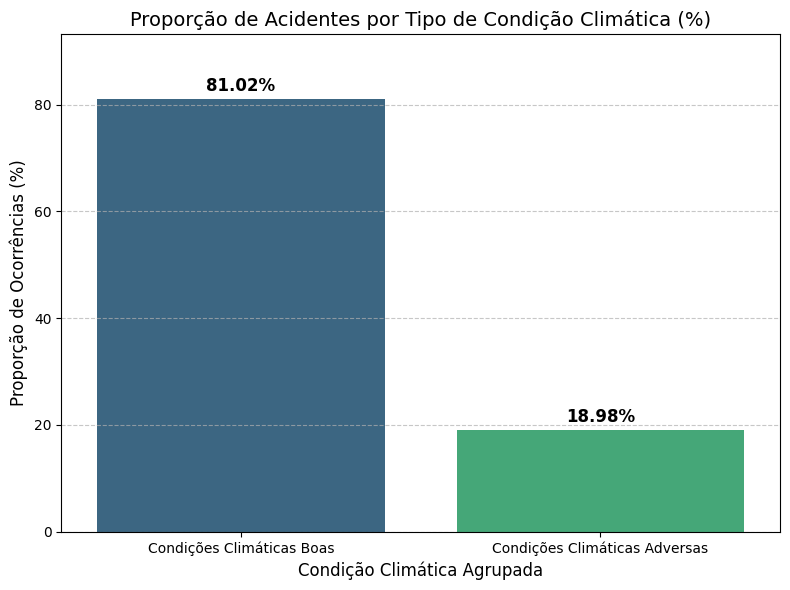

,Quantidade Absoluta,Porcentagem
condicao_metereologica,,
Condições Climáticas Boas,2673,81.02%
Condições Climáticas Adversas,626,18.98%


In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Função de mapeamento para agrupar as condições climáticas
def agrupar_clima(condicao):
    condicao_lower = str(condicao).lower().strip()

    # Condições Climáticas Boas
    if any(clima in condicao_lower for clima in ['sol', 'nublado', 'céu claro', 'ceu claro']):
        return 'Condições Climáticas Boas'
    # Condições Climáticas Adversas
    elif any(clima in condicao_lower for clima in ['chuva', 'garoa', 'chuvisco', 'nevoeiro', 'neblina', 'vento']):
        return 'Condições Climáticas Adversas'
    else:
        return 'Outros'

# 2. Criar a nova coluna agrupada e calcular as porcentagens
clima_agrupado = df['condicao_metereologica'].apply(agrupar_clima)


# Contagem em porcentagem sobre o total de registros válidos
contagem_abs = clima_agrupado.value_counts()
contagem_pct = (clima_agrupado.value_counts() / len(clima_agrupado)) * 100

# 3. Criar o gráfico de barras verticais
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=contagem_pct.index, y=contagem_pct.values, palette='viridis')

# Adicionar os rótulos de porcentagem no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.2f}%',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold',
                xytext=(0, 3), textcoords='offset points')

plt.title('Proporção de Acidentes por Tipo de Condição Climática (%)', fontsize=14)
plt.xlabel('Condição Climática Agrupada', fontsize=12)
plt.ylabel('Proporção de Ocorrências (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, contagem_pct.max() * 1.15)  # Margem no topo para o texto percentual
plt.tight_layout()
plt.show()

# 4. Montar a tabela consolidada com Quantidade Absoluta e Porcentagem
df_resumo_clima = pd.DataFrame({
    'Quantidade Absoluta': contagem_abs,
    'Porcentagem': contagem_pct.round(2).astype(str) + '%'
})

# 5. Exibir a tabela com os valores consolidados
display(df_resumo_clima)


In [31]:
# Aqui pode-se perceber que a maioria dos acidentes ocorreram com condições climáticas favoráveis. Entretanto, uma explicação possível é que a maioria dos dias não
# apresentam condições climáticas adversas. Dessa forma, na célula seguinte resolvemos identificar se o clima adverso é potencialmente mais perigoso para que o acidente
# seja mais grave

# Percentual de acidentes graves por condição climática

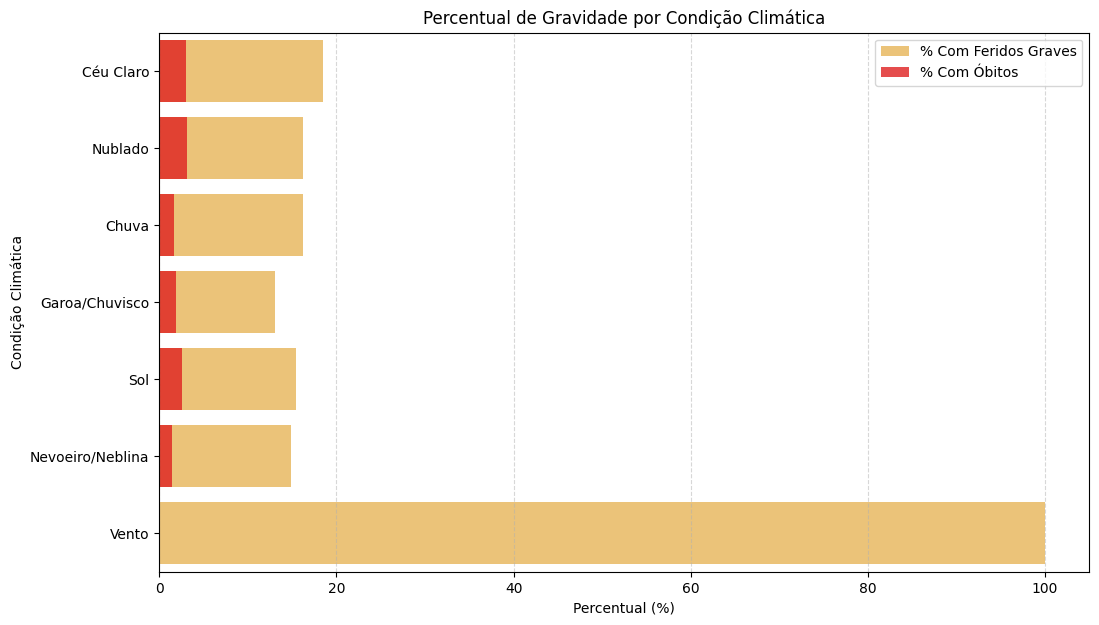

,condicao_metereologica,total,% Feridos Graves,% Óbitos
1,Céu Claro,2036,18.467583,2.996071
4,Nublado,482,16.182573,3.112033
0,Chuva,351,16.239316,1.709402
2,Garoa/Chuvisco,207,13.043478,1.932367
5,Sol,155,15.483871,2.580645
3,Nevoeiro/Neblina,67,14.925373,1.492537
6,Vento,1,100.000000,0.000000


In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garantir que o df local está preparado para o gráfico
df['tem_ferido_grave'] = df['feridos_graves'] > 0
df['tem_obito'] = df['mortos'] > 0

df_clima_filtrado=df[df['condicao_metereologica'] != 'Ignorado']

# Agrupar por condição climática
analise_clima = df_clima_filtrado.groupby('condicao_metereologica').agg(
    total=('id', 'count'),
    feridos_graves=('tem_ferido_grave', 'sum'),
    obitos=('tem_obito', 'sum')
).reset_index()

# Calcular percentuais
analise_clima['% Feridos Graves'] = (analise_clima['feridos_graves'] / analise_clima['total']) * 100
analise_clima['% Óbitos'] = (analise_clima['obitos'] / analise_clima['total']) * 100
analise_clima = analise_clima.sort_values(by='total', ascending=False)

# Plotagem
plt.figure(figsize=(12, 7))
sns.barplot(x='% Feridos Graves', y='condicao_metereologica', data=analise_clima, color='orange', alpha=0.6, label='% Com Feridos Graves')
sns.barplot(x='% Óbitos', y='condicao_metereologica', data=analise_clima, color='red', alpha=0.8, label='% Com Óbitos')

plt.title('Percentual de Gravidade por Condição Climática')
plt.xlabel('Percentual (%)')
plt.ylabel('Condição Climática')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

display(analise_clima[['condicao_metereologica', 'total', '% Feridos Graves', '% Óbitos']])

In [ ]:
# novamente será realizada a binarização da condição climática

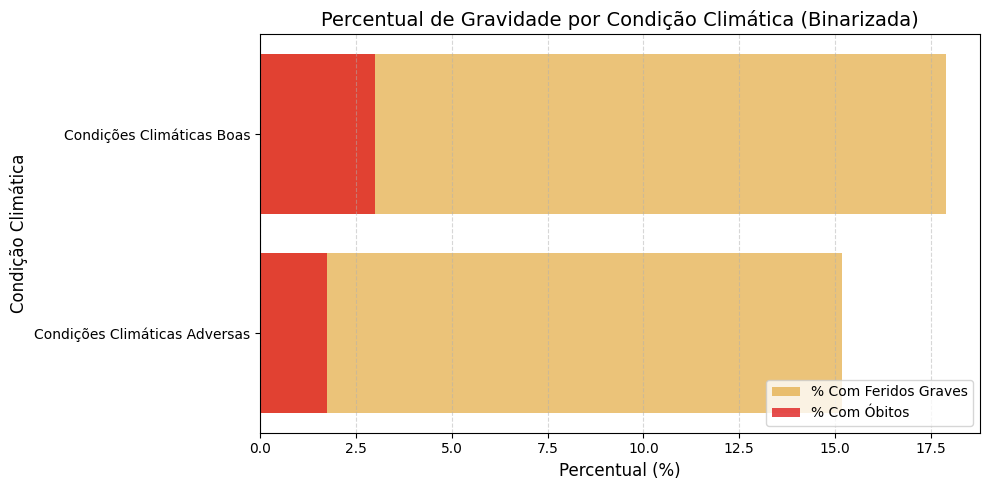

,clima_binario,total,% Feridos Graves,% Óbitos
1,Condições Climáticas Boas,2673,17.88,2.99
0,Condições Climáticas Adversas,626,15.18,1.76


In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir a função de binarização/agrupamento climático
def agrupar_clima(condicao):
    condicao_lower = str(condicao).lower().strip()
    if any(clima in condicao_lower for clima in ['sol', 'nublado', 'céu claro', 'ceu claro']):
        return 'Condições Climáticas Boas'
    elif any(clima in condicao_lower for clima in ['chuva', 'garoa', 'chuvisco', 'nevoeiro', 'neblina', 'vento']):
        return 'Condições Climáticas Adversas'
    else:
        return None

# 2. Preparar as colunas auxiliares no DataFrame
df_clima_filtrado = df[df['condicao_metereologica'] != 'Ignorado'].copy()
df_clima_filtrado['clima_binario'] = df_clima_filtrado['condicao_metereologica'].apply(agrupar_clima)

# Filtrar apenas as duas categorias válidas
df_clima_filtrado = df_clima_filtrado.dropna(subset=['clima_binario'])

df_clima_filtrado['tem_ferido_grave'] = df_clima_filtrado['feridos_graves'] > 0
df_clima_filtrado['tem_obito'] = df_clima_filtrado['mortos'] > 0

# 3. Agrupar pela condição climática binarizada
analise_clima_bin = df_clima_filtrado.groupby('clima_binario').agg(
    total=('id', 'count'),
    feridos_graves=('tem_ferido_grave', 'sum'),
    obitos=('tem_obito', 'sum')
).reset_index()

# 4. Calcular os percentuais de gravidade
analise_clima_bin['% Feridos Graves'] = (analise_clima_bin['feridos_graves'] / analise_clima_bin['total']) * 100
analise_clima_bin['% Óbitos'] = (analise_clima_bin['obitos'] / analise_clima_bin['total']) * 100
analise_clima_bin = analise_clima_bin.sort_values(by='total', ascending=False)

# 5. Plotagem do gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x='% Feridos Graves', y='clima_binario', data=analise_clima_bin, color='orange', alpha=0.6, label='% Com Feridos Graves')
sns.barplot(x='% Óbitos', y='clima_binario', data=analise_clima_bin, color='red', alpha=0.8, label='% Com Óbitos')

plt.title('Percentual de Gravidade por Condição Climática (Binarizada)', fontsize=14)
plt.xlabel('Percentual (%)', fontsize=12)
plt.ylabel('Condição Climática', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Exibir a tabela consolidada
display(analise_clima_bin[['clima_binario', 'total', '% Feridos Graves', '% Óbitos']].round(2))

In [32]:
# de forma pouco intuitiva, mas corroborando com o artigo "Fatores associados ao óbito infanto-juvenil por acidentes de trânsito em rodovias federais brasileiras",
# de Costa, Oliveira-Figueiredo e Rocha, o clima adverso não corrobora para que os acidentes rodoviários sejam mais graves. A hipótese levantada é que condições
# adversas deixam os motoristas mais atentos, o que acaba não sendo um impacto negativo para que o acidente seja mais grave.

A célula a seguir aplica no dataset uma função para a correção de coordenadas, isso porque o dataset original não traz as coordenadas de forma consistente, em um momento usando vírgula como separador, e em outros usando ponto. Além de não manter padronizada a quantidade de dígitos fracionários.

In [152]:
import pandas as pd
import re

def corrigir_coordenada(val):
    if pd.isna(val):
        return val

    val_str = str(val).strip()
    e_negativo = '-' in val_str

    # Extrai apenas os dígitos numéricos (remove vírgulas, pontos e sinais)
    digitos = re.sub(r'\D', '', val_str)

    if not digitos:
        return None

    # Para o Rio Grande do Sul, o padrão é sempre 2 dígitos antes do ponto (ex: 28.xx ou 29.xx para lat, 51.xx para lon)
    val_corrigido = float(f"{digitos[:2]}.{digitos[2:]}")

    return -val_corrigido if e_negativo else val_corrigido

# Aplicando no DataFrame
df['latitude'] = df['latitude'].apply(corrigir_coordenada)
df['longitude'] = df['longitude'].apply(corrigir_coordenada)

Instalação da API do IBGE, será usada para delimitar a região da Serra Gaúcha no mapa

In [153]:
!pip install geobr geopandas

Geração do arquivo .json com a delimitação geográfica da Serra Gaúcha

In [154]:
import geobr
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# 1. Baixar polígonos dos municípios do RS
municipios_rs = geobr.read_municipality(code_muni="RS", year=2020)

# 2. Normalização de nomes (para evitar problemas com acentos/caixa alta)
municipios_rs['name_muni_clean'] = municipios_rs['name_muni'].str.lower().str.strip()
lista_clean = [m.lower().strip() for m in LISTA_MUNICIPIOS]

# 3. Filtrar e unificar a região
serra_gaucha = municipios_rs[municipios_rs['name_muni_clean'].isin(lista_clean)]
unificado = serra_gaucha.dissolve()

# 4. Função para extrair APENAS a borda externa (removendo buracos internos)
def extrair_borda_externa(geom):
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    elif geom.geom_type == 'MultiPolygon':
        poligonos_sem_buracos = [Polygon(p.exterior) for p in geom.geoms]
        return MultiPolygon(poligonos_sem_buracos)
    return geom

# Aplicar a limpeza de geometria
fronteira_limpa = unificado.copy()
fronteira_limpa['geometry'] = fronteira_limpa['geometry'].apply(extrair_borda_externa)

# 5. Salvar o arquivo GeoJSON corrigido
fronteira_limpa.to_file("serra_gaucha.geojson", driver="GeoJSON")

print("Arquivo 'serra_gaucha.geojson' gerado com sucesso!")

Arquivo 'serra_gaucha.geojson' gerado com sucesso!


# Mapa de calor da localização das ocorrências

In [155]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import re
import json

# 1. Carregar os dados
df_mapa = df.copy()

# 2. Corrigir coordenadas
def corrigir_coordenada(val):
    if pd.isna(val):
        return val
    val_str = str(val).strip()
    e_negativo = '-' in val_str
    digitos = re.sub(r'\D', '', val_str)
    if not digitos:
        return None
    val_corrigido = float(f"{digitos[:2]}.{digitos[2:]}")
    return -val_corrigido if e_negativo else val_corrigido

df['latitude'] = df['latitude'].apply(corrigir_coordenada)
df['longitude'] = df['longitude'].apply(corrigir_coordenada)

# 3. Remover coordenadas nulas
df_mapa = df.dropna(subset=['latitude', 'longitude'])

# 4. Criar o mapa base
centro_lat = df_mapa['latitude'].mean()
centro_lon = df_mapa['longitude'].mean()

mapa_calor = folium.Map(location=[centro_lat, centro_lon], zoom_start=10)

# 5. Adicionar a camada de calor (HeatMap)
coordenadas = df_mapa[['latitude', 'longitude']].values.tolist()
HeatMap(coordenadas, radius=12, blur=15).add_to(mapa_calor)

# -------------------------------------------------------------
# 6. ADICIONAR O CONTORNO TRACEJADO DA SERRA GAÚCHA
# -------------------------------------------------------------

# Estilo visual da linha do perímetro
estilo_fronteira = {
    'fillColor': 'transparent', # Sem preenchimento de cor dentro do mapa
    'color': '#ed5a5a',         # Cor da linha (Laranja escuro/Destaque)
    'weight': 3,               # Espessura da linha
    'dashArray': '6, 6',       # Define o padrão TRACEJADO (6px linha, 6px espaço)
    'fillOpacity': 0.0
}

folium.GeoJson(
     'serra_gaucha.geojson',
     name='Delimitação Serra Gaúcha',
     style_function=lambda x: estilo_fronteira
 ).add_to(mapa_calor)

# Exibir o mapa interativo
mapa_calor

# Mapa de localização agrupada das ocorrências

In [156]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import re

# 1. Carregar os dados
df_mapa = df.copy()

# 2. Corrigir as coordenadas
def corrigir_coordenada(val):
    if pd.isna(val):
        return val
    val_str = str(val).strip()
    e_negativo = '-' in val_str
    digitos = re.sub(r'\D', '', val_str)
    if not digitos:
        return None
    val_corrigido = float(f"{digitos[:2]}.{digitos[2:]}")
    return -val_corrigido if e_negativo else val_corrigido

df['latitude'] = df['latitude'].apply(corrigir_coordenada)
df['longitude'] = df['longitude'].apply(corrigir_coordenada)

# 3. Filtrar coordenadas válidas
df_mapa = df.dropna(subset=['latitude', 'longitude'])

# 4. Criar mapa base
centro_lat = df_mapa['latitude'].mean()
centro_lon = df_mapa['longitude'].mean()

mapa_cluster = folium.Map(location=[centro_lat, centro_lon], zoom_start=10)
marker_cluster = MarkerCluster().add_to(mapa_cluster)

# 5. Adicionar marcadores no grupo
for idx, row in df_mapa.iterrows():
    # Define a cor do ícone pela gravidade do acidente
    cor = 'red' if row['classificacao_acidente'] == 'Com Vítimas Fatais' else \
          ('orange' if row['classificacao_acidente'] == 'Com Vítimas Feridas' else 'green')

    texto_popup = f"""
    <b>Classificação:</b> {row['classificacao_acidente']}<br>
    <b>Clima:</b> {row['condicao_metereologica']}<br>
    <b>Causa:</b> {row['causa_acidente']}<br>
    <b>Traçado:</b> {row['tracado_via']}<br>
    <b>KM:</b> {row['km']}
    """

    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(texto_popup, max_width=300),
        icon=folium.Icon(color=cor, icon='info-sign')
    ).add_to(marker_cluster)

# -------------------------------------------------------------
# 6. ADICIONAR O CONTORNO TRACEJADO DA SERRA GAÚCHA
# -------------------------------------------------------------

# Estilo visual da linha do perímetro
estilo_fronteira = {
    'fillColor': 'transparent', # Sem preenchimento de cor dentro do mapa
    'color': '#ed5a5a',         # Cor da linha (Laranja escuro/Destaque)
    'weight': 3,               # Espessura da linha
    'dashArray': '6, 6',       # Define o padrão TRACEJADO (6px linha, 6px espaço)
    'fillOpacity': 0.0
}

folium.GeoJson(
     'serra_gaucha.geojson',
     name='Delimitação Serra Gaúcha',
     style_function=lambda x: estilo_fronteira
 ).add_to(mapa_cluster)

# Exibir no notebook
mapa_cluster

### Análise de Acidentes Graves (Feridos Graves ou Vítimas Fatais)
Este mapa foca exclusivamente nas ocorrências de maior gravidade para identificar trechos críticos das rodovias.

In [157]:
import pandas as pd
import folium
from folium.plugins import HeatMap, MarkerCluster
import re

# 1. Recarregar dados para garantir que 'df' existe no escopo local desta célula
df_mapa = df.copy()

# 2. Corrigir as coordenadas
def corrigir_coordenada(val):
    if pd.isna(val):
        return val
    val_str = str(val).strip()
    e_negativo = '-' in val_str
    digitos = re.sub(r'\D', '', val_str)
    if not digitos: return None
    val_corrigido = float(f"{digitos[:2]}.{digitos[2:]}")
    return -val_corrigido if e_negativo else val_corrigido

df['latitude'] = df['latitude'].apply(corrigir_coordenada)
df['longitude'] = df['longitude'].apply(corrigir_coordenada)

# 3. Filtrar apenas acidentes com feridos graves ou mortos
df_grave = df[(df['feridos_graves'] > 0) | (df['mortos'] > 0)].copy()
df_grave_mapa = df_grave.dropna(subset=['latitude', 'longitude'])

# 4. Criar mapa base
centro_lat = df_grave_mapa['latitude'].mean()
centro_lon = df_grave_mapa['longitude'].mean()
mapa_grave = folium.Map(location=[centro_lat, centro_lon], zoom_start=9)

# 5. Adicionar visualizações
HeatMap(df_grave_mapa[['latitude', 'longitude']].values.tolist(), radius=15, blur=20, name='Densidade').add_to(mapa_grave)


for idx, row in df_grave_mapa.iterrows():
    cor = 'black' if row['mortos'] > 0 else 'darkred'
    texto = f"Mortos: {row['mortos']} | Feridos Graves: {row['feridos_graves']}<br>Causa: {row['causa_acidente']}"
    folium.Marker(location=[row['latitude'], row['longitude']], popup=folium.Popup(texto, max_width=300), icon=folium.Icon(color=cor))

# -------------------------------------------------------------
# 6. ADICIONAR O CONTORNO TRACEJADO DA SERRA GAÚCHA
# -------------------------------------------------------------

# Estilo visual da linha do perímetro
estilo_fronteira = {
    'fillColor': 'transparent', # Sem preenchimento de cor dentro do mapa
    'color': '#ed5a5a',         # Cor da linha (Laranja escuro/Destaque)
    'weight': 3,               # Espessura da linha
    'dashArray': '6, 6',       # Define o padrão TRACEJADO (6px linha, 6px espaço)
    'fillOpacity': 0.0
}

folium.GeoJson(
     'serra_gaucha.geojson',
     name='Delimitação Serra Gaúcha',
     style_function=lambda x: estilo_fronteira
 ).add_to(mapa_grave)

folium.LayerControl().add_to(mapa_grave)
print(f'Total de acidentes graves: {len(df_grave_mapa)}')
mapa_grave

Total de acidentes graves: 639


# Classificação do acidente pelo pior caso de uma vítima

Na próxima célula, os acidentes são classificados pela pior condição que uma vítima teve, fatalidade, ferida com gravidade, ferida levemente ou ilesa. Destacamos também os casos "ignorados", aqueles que as vítimas do acidente receberam apenas status de ignorado e não foi possível encaixá-las em outra categoria.

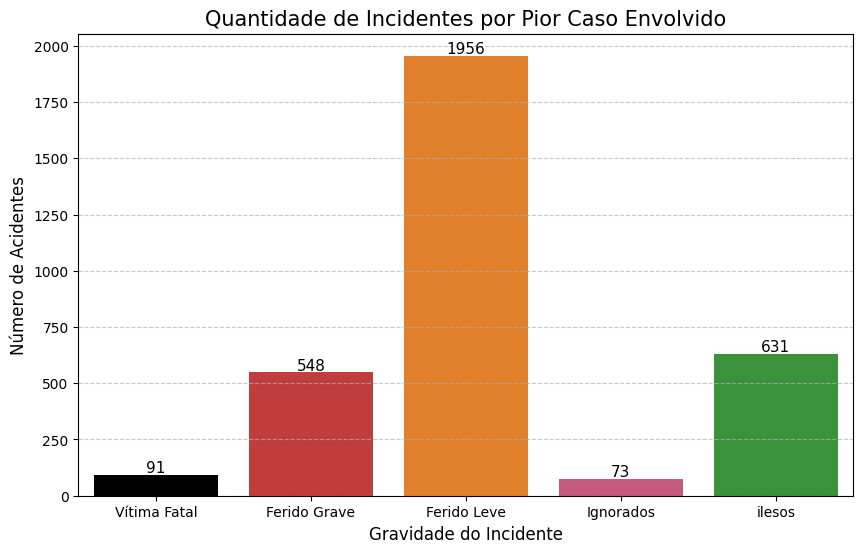

In [158]:
def definir_pior_caso(row):
    if row['mortos'] > 0:
        return 'Vítima Fatal'
    elif row['feridos_graves'] > 0:
        return 'Ferido Grave'
    elif row['feridos_leves'] > 0:
        return 'Ferido Leve'
    elif row['ilesos'] > 0:
        return 'ilesos'
    else:
        return 'Ignorados'

# Criando a coluna de severidade máxima
df['severidade_maxima'] = df.apply(definir_pior_caso, axis=1)

# Contagem das categorias
contagem_severidade = df['severidade_maxima'].value_counts().reindex([
    'Vítima Fatal', 'Ferido Grave', 'Ferido Leve', 'Ignorados', 'ilesos'
])

# Plotagem
plt.figure(figsize=(10, 6))
colors = ['#000000', '#d62728', '#ff7f0e', '#d64877', '#2ca02c']
ax = sns.barplot(x=contagem_severidade.index, y=contagem_severidade.values, palette=colors)

# Adicionando os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Quantidade de Incidentes por Pior Caso Envolvido', fontsize=15)
plt.xlabel('Gravidade do Incidente', fontsize=12)
plt.ylabel('Número de Acidentes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# foi possível observar 75 casos de ignorados, como essa é a nossa variável alvo no modelo de machine learning, não podemos considerar essas entradas.
# felizmente elas são pouco representativas e serão removidas pelo código da célula abaixo

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar descartando os casos onde a severidade máxima foi definida como 'Ignorados'
df = df[df['severidade_maxima'] != 'Ignorados'].copy()

# 2. Métricas de limpeza
total_depois = len(df)
removidos = total_antes - total_depois

print("Total de ocorrências no dataset antes da limpeza: 3299")
print(f"Total de ocorrências restantes no dataset: {total_depois}")

Total de ocorrências no dataset antes da limpeza: 3299
Total de ocorrências restantes no dataset: 3226


Finalizada a limpeza dos dados, a célula seguinte executa o download da versão limpa do csv, com 3226 entradas

In [160]:
from google.colab import files

# 1. Salva o DataFrame filtrado/limpo como um arquivo CSV na máquina virtual
nome_arquivo = 'Dados_Rodovia_Limpo.csv'
df.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')

# 2. Dispara o download automático do arquivo para o seu computador
files.download(nome_arquivo)

print(f"Download iniciado para '{nome_arquivo}' com {len(df)} registros.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado para 'Dados_Rodovia_Limpo.csv' com 3226 registros.


# Feature Engineering





In [ ]:
# A primeira rodada do modelo, realizando a previsão de gravidade do acidente em 4 categorias: fatal, feridos graves, feridos leves e ilesos, resultou em um F1-score
# de 29,8%, um resultado muito ruim

# dessa forma, a primeira decisão tomada foi a binarização da gravidade do acidente, fatal/gravemente ferido e levemente ferido/ileso. Essa decisão foi apoiada
# em uma possível aplicação futura que ajude a determinar a urgência de deslocamento de unidades móveis de serviço médico, pois um acidente mais grave, todo segundo
# importa para a recuperação do paciente

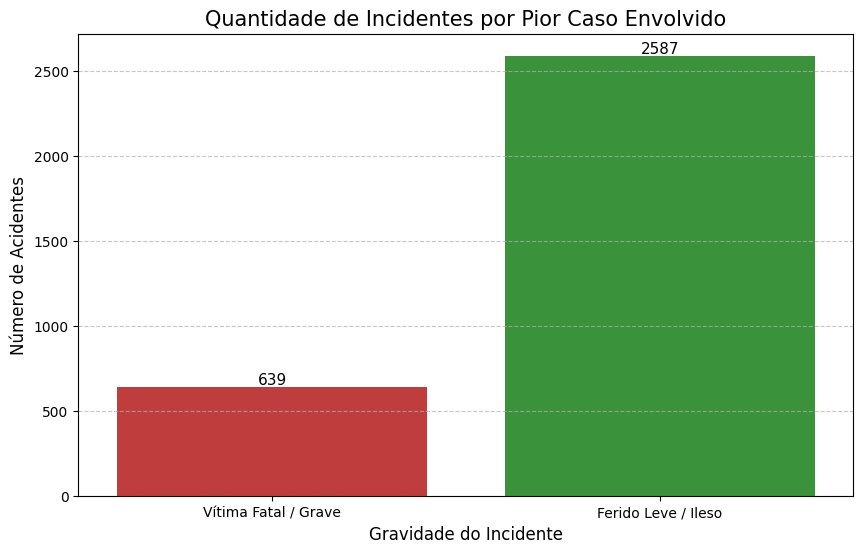

In [161]:
def definir_pior_caso(row):
    if row['mortos'] > 0:
        return 'Vítima Fatal / Grave'
    elif row['feridos_graves'] > 0:
        return 'Vítima Fatal / Grave'
    else:
        return 'Ferido Leve / Ileso'

# Criando a coluna de severidade máxima
df['severidade_maxima'] = df.apply(definir_pior_caso, axis=1)

# Contagem das categorias
contagem_severidade = df['severidade_maxima'].value_counts().reindex([
    'Vítima Fatal / Grave', 'Ferido Leve / Ileso'
])

# Plotagem
plt.figure(figsize=(10, 6))
colors = ['#d62728', '#2ca02c']
ax = sns.barplot(x=contagem_severidade.index, y=contagem_severidade.values, palette=colors)

# Adicionando os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Quantidade de Incidentes por Pior Caso Envolvido', fontsize=15)
plt.xlabel('Gravidade do Incidente', fontsize=12)
plt.ylabel('Número de Acidentes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Tendo essa classificação, para o dataset não é mais necessário ter as colunas de quantidades de vítimas fatais, feridas e ilesas. A exclusão é realizada na célula abaixo

In [162]:
# Lista de colunas pós-sinistro de contagem direta de vítimas a serem removidas
colunas_vitimas = ['mortos', 'feridos_graves', 'feridos_leves', 'ilesos', 'ignorados', 'feridos']

# Remover do DataFrame principal caso ainda existam
df.drop(columns=[col for col in colunas_vitimas if col in df.columns], inplace=True)

print("Colunas de contagem de vítimas removidas com sucesso!")
print(f"Colunas restantes no dataset ({df.shape[1]} colunas):")
print(df.columns.tolist())

Colunas de contagem de vítimas removidas com sucesso!
Colunas restantes no dataset (37 colunas):
['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'area_urbana', 'pessoas', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'ano_mes', 'mes', 'dia_da_semana', 'nome_dia_da_semana', 'hora_int', 'eh_grave', 'eh_fatal', 'leve', 'grave_ou_fatal', 'tem_ferido_grave', 'tem_obito', 'severidade_maxima']


Rodando o modelo dessa forma, atingimos um resultado bem mais expressivo:
F1-score: 56,23% e Acurácia: 68,72%


Para tornar o modelo mais simples e buscar um resultado mais favorável, optamos por binarizar as condições climáticas no dataset, condição climática favorável e adversa

In [163]:
import pandas as pd

# 1. Função de mapeamento para agrupar as condições climáticas
def agrupar_clima(condicao):
    condicao_lower = str(condicao).lower().strip()

    # Condições Climáticas Boas (Sol, Céu Claro, Nublado)
    if any(clima in condicao_lower for clima in ['sol', 'nublado', 'céu claro', 'ceu claro']):
        return 'Condições Climáticas Boas'
    # Condições Climáticas Adversas (Chuva, Garoa, Neblina, Vento, etc.)
    elif any(clima in condicao_lower for clima in ['chuva', 'garoa', 'chuvisco', 'nevoeiro', 'neblina', 'vento']):
        return 'Condições Climáticas Adversas'
    else:
        return 'Outros'

# 2. Criar a coluna textual binarizada
df['clima_binario'] = df['condicao_metereologica'].apply(agrupar_clima)


# 4. Exibir a contagem e a proporção para validação
resumo_clima = df['clima_binario'].value_counts()
proporcao_clima = (df['clima_binario'].value_counts(normalize=True) * 100).round(2)

df_validacao_clima = pd.DataFrame({
    'Quantidade Absoluta': resumo_clima,
    'Proporção (%)': proporcao_clima.astype(str) + '%'
})

print("Binarização da Condição Climática concluída com sucesso!\n")
display(df_validacao_clima)

Binarização da Condição Climática concluída com sucesso!



,Quantidade Absoluta,Proporção (%)
clima_binario,,
Condições Climáticas Boas,2622,81.28%
Condições Climáticas Adversas,604,18.72%


Tendo essa classificação, para o dataset não é mais necessário ter a coluna de condição climática original. A exclusão é realizada na célula abaixo

In [164]:
# Remover a coluna original de condição meteorológica
if 'condicao_metereologica' in df.columns:
    df.drop(columns=['condicao_metereologica'], inplace=True)
    print("Coluna 'condicao_metereologica' original removida com sucesso!")

# Verificar as colunas restantes no DataFrame
print("Colunas atuais do DataFrame:")
print(df.columns.tolist())

Coluna 'condicao_metereologica' original removida com sucesso!
Colunas atuais do DataFrame:
['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'tipo_pista', 'tracado_via', 'area_urbana', 'pessoas', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'ano_mes', 'mes', 'dia_da_semana', 'nome_dia_da_semana', 'hora_int', 'eh_grave', 'eh_fatal', 'leve', 'grave_ou_fatal', 'tem_ferido_grave', 'tem_obito', 'severidade_maxima', 'clima_binario']


Agora é necessário remover as colunas que não ajudam o modelo de machine learning, são redundantes ou provocarão data leakage

In [165]:
# Lista de colunas a remover definitivamente
colunas_para_remover = [
    'classificacao_acidente',
    'eh_grave',
    'eh_fatal',
    'leve',
    'grave_ou_fatal',
    'tem_ferido_grave',
    'tem_obito',
    'pessoas',
    'causa_acidente',
    'tipo_acidente',
    'id',
    'uf',
    'regional',
    'delegacia',
    'uop',
    'data_inversa',
    'horario',
    'nome_dia_da_semana',
    'dia_semana',
    'ano_mes',
    'latitude',
    'longitude'
]

# Remover apenas as que de fato existem no DataFrame
df.drop(columns=[col for col in colunas_para_remover if col in df.columns], inplace=True)

print(f"Limpeza realizada com sucesso!")
print(f"Total de colunas restantes no dataset: {df.shape[1]}")
print("\nColunas mantidas no DataFrame:")
print(df.columns.tolist())

Limpeza realizada com sucesso!
Total de colunas restantes no dataset: 15

Colunas mantidas no DataFrame:
['br', 'km', 'municipio', 'fase_dia', 'sentido_via', 'tipo_pista', 'tracado_via', 'area_urbana', 'veiculos', 'ano', 'mes', 'dia_da_semana', 'hora_int', 'severidade_maxima', 'clima_binario']


Download do dataset com feature engineering e pronto para o machine learning

In [166]:
from google.colab import files

# 1. Salva o DataFrame filtrado/limpo como um arquivo CSV na máquina virtual
nome_arquivo = 'Dados_Rodovia_Feature_Engineering.csv'
df.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')

# 2. Dispara o download automático do arquivo para o seu computador
files.download(nome_arquivo)

print(f"Download iniciado para '{nome_arquivo}' com {len(df)} registros.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado para 'Dados_Rodovia_Feature_Engineering.csv' com 3226 registros.


# Machine Learning

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*Found unknown categories.*")

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Reprodutibilidade
RANDOM_STATE = 45

Divisão entre dados e atributo-alvo

In [204]:
import pandas as pd

# 1. Definir o y (Variável Alvo)
y = df['severidade_maxima']

# 2. Lista completa e filtrada de colunas a remover de X
colunas_para_remover = [
    # --- Target e Rótulos Equivalentes ---
    'severidade_maxima'
]

# 3. Filtrar apenas as colunas que efetivamente existem no df
colunas_existentes = [col for col in colunas_para_remover if col in df.columns]
X = df.drop(columns=colunas_existentes)

# 4. Validação final
print(f"Tamanho do dataset: {X.shape[0]} linhas")
print(f"Total de features preditivas em X: {X.shape[1]}")
print("\nFeatures mantidas em X para o modelo:")
for i, col in enumerate(X.columns, 1):
    print(f"{i:02d}. {col}")

Tamanho do dataset: 3226 linhas
Total de features preditivas em X: 14

Features mantidas em X para o modelo:
01. br
02. km
03. municipio
04. fase_dia
05. sentido_via
06. tipo_pista
07. tracado_via
08. area_urbana
09. veiculos
10. ano
11. mes
12. dia_da_semana
13. hora_int
14. clima_binario


Normalizar as variáveis, utilizando MinMaxScaler para manter a proporção de valores entre diferentes features e OneHotEncoder para os atributos categóricos

In [205]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# 1. Identificação automática das colunas numéricas e categóricas do seu X atual
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

print(f"Features Numéricas ({len(numerical_cols)}): {list(numerical_cols)}")
print(f"Features Categóricas ({len(categorical_cols)}): {list(categorical_cols)}\n")

# 2. Definição do Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(feature_range=(0, 1)), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print("Preprocessor configurado com sucesso!")

Features Numéricas (7): ['br', 'km', 'veiculos', 'ano', 'mes', 'dia_da_semana', 'hora_int']
Features Categóricas (7): ['municipio', 'fase_dia', 'sentido_via', 'tipo_pista', 'tracado_via', 'area_urbana', 'clima_binario']

Preprocessor configurado com sucesso!


Binarizar em 0 ou 1 a variável alvo, obrigatório para alguns algoritmos

In [206]:
from sklearn.preprocessing import LabelEncoder

# Instancia e transforma a variável alvo para inteiros (0, 1, 2, ...)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['severidade_maxima'])

# Caso já tenha dividido X_train e y_train, aplique diretamente no y_train:
# y_train = label_encoder.fit_transform(y_train)

In [207]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2580, 14)
Test shape: (646, 14)


In [208]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# 1. Validação Cruzada Estratificada para Classificação
cv = StratifiedKFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)

# 2. Modelos de Classificação (Substituído LogisticRegression no nome correto)
models = {
    "K3NN": KNeighborsClassifier(n_neighbors=3),
    "K5NN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=RANDOM_STATE),
    "DecisionTreeSemPoda": DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    "NeuralNetwork": MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=RANDOM_STATE),
    "RandomForestSemPoda": RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    "RandomForestOtimizada": RandomForestClassifier(class_weight='balanced', max_depth=6, random_state=RANDOM_STATE, n_estimators=190, min_samples_split=5, min_samples_leaf=2),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced')
    }

# Define as métricas apropriadas para classificação multiclasse
scoring = {
    'f1_macro': 'f1_macro',
    'accuracy': 'accuracy'
}

results = {}

print("\n===== SPOT-CHECKING (CLASSIFICAÇÃO) =====")

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # Utiliza cross_validate para calcular múltiplas métricas em uma única execução
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    f1_mean = scores['test_f1_macro'].mean()
    f1_std = scores['test_f1_macro'].std()
    acc_mean = scores['test_accuracy'].mean()
    acc_std = scores['test_accuracy'].std()

    results[name] = {
        'f1_macro_mean': f1_mean,
        'f1_macro_std': f1_std,
        'acc_mean': acc_mean,
        'acc_std': acc_std
    }

    print(f"{name:22s} | F1-Macro Médio: {f1_mean:.4f} (±{f1_std:.4f}) | Acurácia Média: {acc_mean:.4f} (±{acc_std:.4f})")


===== SPOT-CHECKING (CLASSIFICAÇÃO) =====
K3NN                   | F1-Macro Médio: 0.5145 (±0.0252) | Acurácia Média: 0.7465 (±0.0199)
K5NN                   | F1-Macro Médio: 0.5035 (±0.0153) | Acurácia Média: 0.7729 (±0.0120)
LogisticRegression     | F1-Macro Médio: 0.5713 (±0.0187) | Acurácia Média: 0.6484 (±0.0215)
DecisionTree           | F1-Macro Médio: 0.5310 (±0.0236) | Acurácia Média: 0.6694 (±0.0452)
DecisionTreeSemPoda    | F1-Macro Médio: 0.5271 (±0.0175) | Acurácia Média: 0.6981 (±0.0081)
NeuralNetwork          | F1-Macro Médio: 0.4448 (±0.0005) | Acurácia Média: 0.8012 (±0.0016)
RandomForest           | F1-Macro Médio: 0.5603 (±0.0198) | Acurácia Média: 0.7667 (±0.0162)
RandomForestSemPoda    | F1-Macro Médio: 0.4692 (±0.0062) | Acurácia Média: 0.7946 (±0.0073)
RandomForestOtimizada  | F1-Macro Médio: 0.5704 (±0.0269) | Acurácia Média: 0.6996 (±0.0196)
XGBoost                | F1-Macro Médio: 0.5149 (±0.0177) | Acurácia Média: 0.7647 (±0.0100)
LightGBM               | F1

In [ ]:
# Foram utilizadas duas métricas para a avaliação dos modelos desenvolvidos: F1-Score e Acurácia. Entretanto, eles não possuem um mesmo peso, pois se tratar de um
# problema com classes desequilibradas. Por exemplo, nesse conjunto de dados, a classe mais representativa (acidentes leves) era 81% do dataset. Sendo assim, um modelo
# que classifica tudo como acidente leve, teria uma acurácia de 81%, um número que parece bom, mas na verdade é enganoso. Por isso, a acurácia é tratada como um critério
# de desempate, dando mais importância ao F1-Score. O F1-Score realiza uma média harmônica entre a acurácia e o recall, dessa forma, dará maior peso para a métrica que
# for pior. Considerar o recall é muito importante neste estudo, pois ele foca nos falsos negativo, que é o que mais queremos evitar. Nesse contexto, o falso negativo é
# um acidente grave, mas que o modelo acreditou ser leve, dessa forma, mandou o atendimento móvel sem a devida urgência. Os falsos positivos são o inverso, acidentes
# leves, mas que o modelo classificou como grave, e mandou um resgate móvel com mais urgência do que o necessário, o que é um tradeoff que estamos disposto a correr.
# Por fim, o modelo que tiver o melhor F1-Score será considerado o melhor.


In [209]:
import pandas as pd

# 1. Converter o dicionário de resultados em um DataFrame
df_resultados = pd.DataFrame.from_dict(results, orient='index')

# 2. Ordenar pelo F1-Macro Médio (do maior para o menor)
df_rank = df_resultados.sort_values(by='f1_macro_mean', ascending=False)

# 3. Selecionar os 2 melhores modelos
top_2 = df_rank.head(2)

print("===== TOP 2 MODELOS (MELHOR F1-MACRO) =====\n")
for i, (nome, row) in enumerate(top_2.iterrows(), 1):
    f1_m = row['f1_macro_mean']
    f1_s = row['f1_macro_std']
    acc_m = row['acc_mean']
    acc_s = row['acc_std']

    print(f"🏆 {i}º Lugar: {nome}")
    print(f"   • F1-Macro Médio: {f1_m:.4f} (±{f1_s:.4f})")
    print(f"   • Acurácia Média:  {acc_m:.4f} (±{acc_s:.4f})\n")

===== TOP 2 MODELOS (MELHOR F1-MACRO) =====

🏆 1º Lugar: LightGBM
   • F1-Macro Médio: 0.5732 (±0.0132)
   • Acurácia Média:  0.7140 (±0.0077)

🏆 2º Lugar: LogisticRegression
   • F1-Macro Médio: 0.5713 (±0.0187)
   • Acurácia Média:  0.6484 (±0.0215)



#Matriz de Confusão dos Modelos

LightGBM

[LightGBM] [Info] Number of positive: 511, number of negative: 2069
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 396
[LightGBM] [Info] Number of data points in the train set: 2580, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

   Não Grave       0.84      0.79      0.82       518
 Grave/Fatal       0.31      0.38      0.35       128

    accuracy                           0.71       646
   macro avg       0.58      0.59      0.58       646
weighted avg       0.73      0.71      0.72       646



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


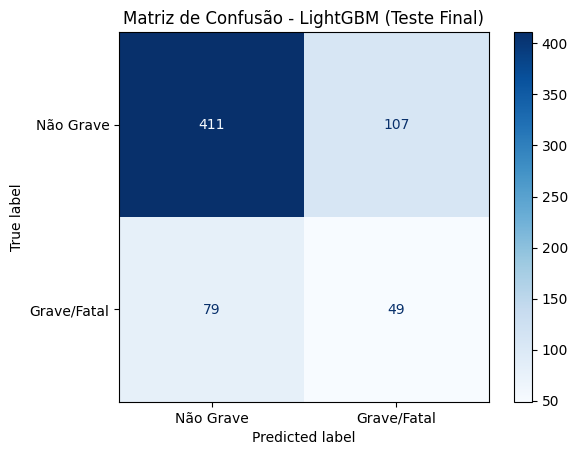

In [210]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instanciando o modelo campeão
modelo_campeao = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

# Treinamento e Predição no Teste Final
modelo_campeao.fit(X_train, y_train)
y_pred_test = modelo_campeao.predict(X_test)

# Exibição das Métricas
print(classification_report(y_test, y_pred_test, target_names=['Não Grave', 'Grave/Fatal']))

# Plot da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Grave', 'Grave/Fatal'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - LightGBM (Teste Final)')
plt.show()

Regressão Logística

              precision    recall  f1-score   support

   Não Grave       0.84      0.66      0.74       518
 Grave/Fatal       0.26      0.49      0.34       128

    accuracy                           0.63       646
   macro avg       0.55      0.58      0.54       646
weighted avg       0.73      0.63      0.66       646



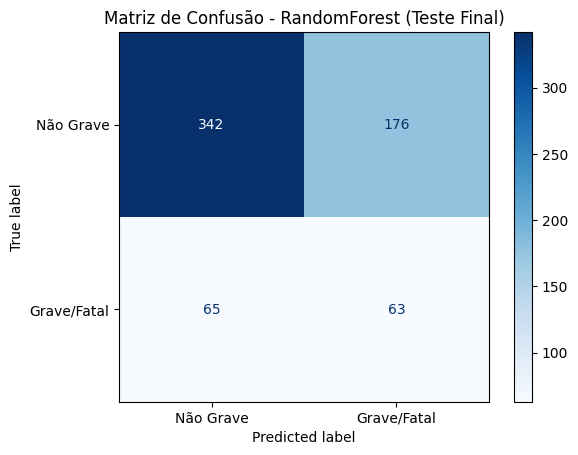

In [211]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instanciando o modelo vice_campeão
modelo_vicecampeao = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

# Treinamento e Predição no Teste Final
modelo_vicecampeao.fit(X_train, y_train)
y_pred_test = modelo_vicecampeao.predict(X_test)

# Exibição das Métricas
print(classification_report(y_test, y_pred_test, target_names=['Não Grave', 'Grave/Fatal']))

# Plot da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Grave', 'Grave/Fatal'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - RandomForest (Teste Final)')
plt.show()

In [ ]:
# embora o modelo de regressão logística obteve menos falsos positivos com os dados de teste, a falta de acurácia foi determinante para diminuir o seu nível no F1-Score,
# sendo assim, o light GBM se mostrou o modelo mais confiável por ter a melhor combinação entre precisão e recall

# Para a avaliação e interpretabilidade do modelo, vamos apenas levar em consideração o LightGBM, pois se mostrou o melhor modelo através dos critérios definidos:
# F1-Score Light GBM no conjunto de teste = 58%
# F1-Score Regressão Logística no conjunto de teste = 54%

# Interpretabilidade do Modelo

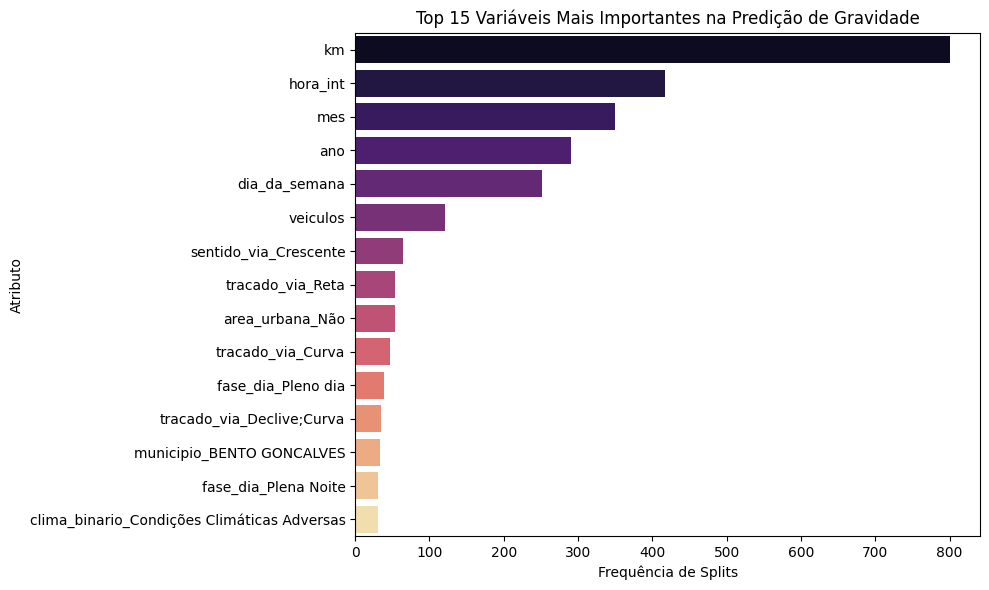

In [214]:
# ANALISE DE IMPORTANCIA DAS VARIAVEIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extrair nomes dos atributos após o OneHotEncoder do Pipeline
cat_feature_names = modelo_campeao.named_steps['preprocessing'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, cat_feature_names])

# 2. Obter as importâncias do LightGBM
importances = modelo_campeao.named_steps['model'].feature_importances_

# 3. Criar DataFrame e ordenar
df_imp = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plotar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp.head(15), x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Variáveis Mais Importantes na Predição de Gravidade')
plt.xlabel('Frequência de Splits')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

In [ ]:
# Aqui podemos identificar que a quilometragem da via tem um papel importante na previsibilidade da gravidade, assim como hora e mês. Mas não sabemos se essa
# influência leva na diminuição ou aumento da gravidade. Veremos isso no gráfico SHAP mais adiante

# Influência da quilometragem na gravidade

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

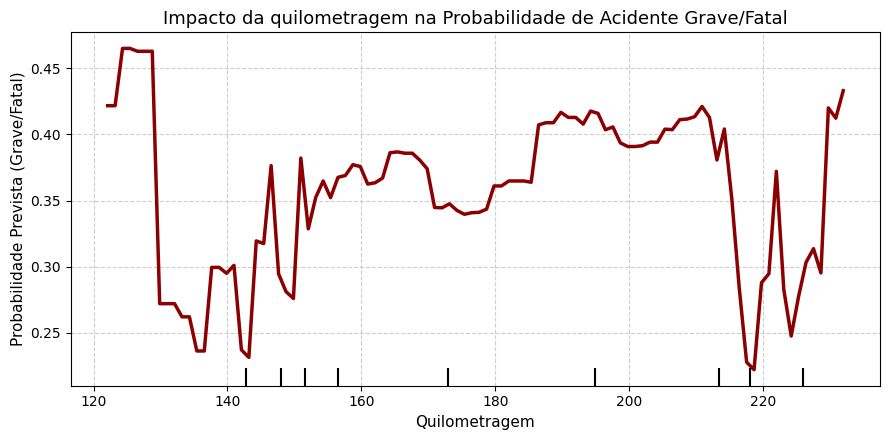

In [213]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(9, 4.5))

# Usando X_train no lugar de X_bin
PartialDependenceDisplay.from_estimator(
    modelo_campeao,
    X_train,
    ['km'],
    ax=ax,
    line_kw={'color': 'darkred', 'linewidth': 2.5}
)

plt.title('Impacto da quilometragem na Probabilidade de Acidente Grave/Fatal', fontsize=13)
plt.xlabel('Quilometragem', fontsize=11)
plt.ylabel('Probabilidade Prevista (Grave/Fatal)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# O gráfico da influência da quilometragem na gravidade do acidente é uma importante análise, pois pode demonstrar pontos de atenção nas rodovias.
# Para um estudo futuro, seria interessante separar cada uma das rodovias para entender os pontos que trazem maior periculosidade em cada uma.

# Gráfico SHAP

/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


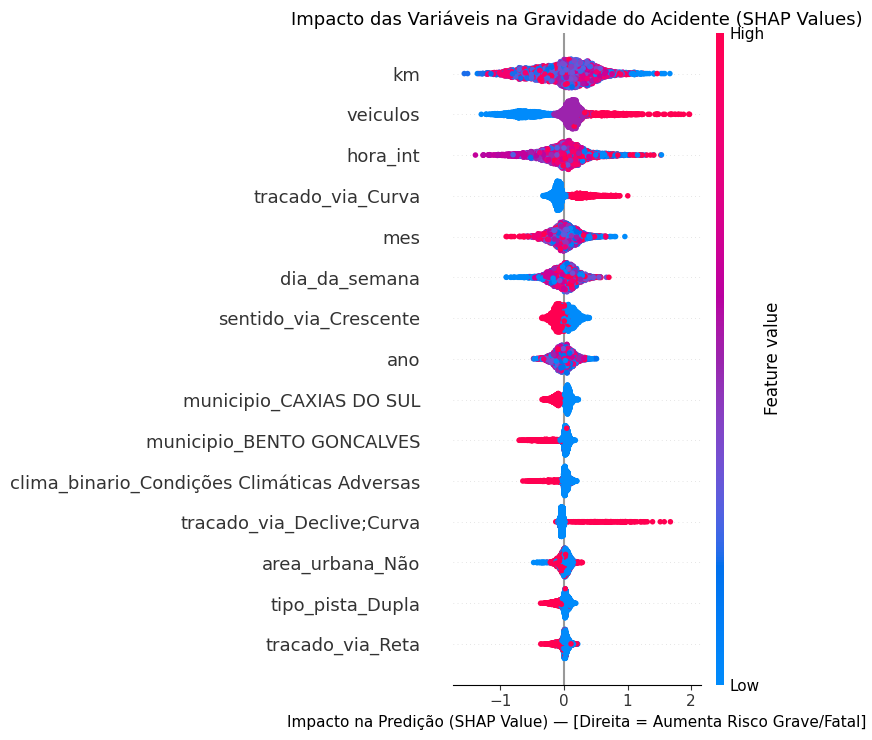

In [217]:
!pip install shap -q

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extrair os dados transformados pelo preprocessor do LightGBM
X_trans = modelo_campeao.named_steps['preprocessing'].transform(X)

# Obter nomes das colunas após One-Hot Encoding
cat_feature_names = modelo_campeao.named_steps['preprocessing'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, cat_feature_names])

# Converter para DataFrame formatado
X_trans_df = pd.DataFrame(X_trans, columns=all_feature_names)

# 2. Criar o explicador SHAP para o modelo de árvore (LightGBM)
explainer = shap.TreeExplainer(modelo_campeao.named_steps['model'])
shap_values = explainer.shap_values(X_trans_df)

# Se o SHAP retornar uma lista (duas classes), pegamos os valores da classe 1 (Grave/Fatal)
if isinstance(shap_values, list):
    shap_vals_grave = shap_values[1]
else:
    shap_vals_grave = shap_values

# 3. Plotar o Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_grave, X_trans_df, max_display=15, show=False)
plt.title('Impacto das Variáveis na Gravidade do Acidente (SHAP Values)', fontsize=13)
plt.xlabel('Impacto na Predição (SHAP Value) — [Direita = Aumenta Risco Grave/Fatal]', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# O gráfico SHAP é uma das ferramentas mais poderosas para interpretar modelos de aprendizado de máquina, pois mostra não só os atributos que mais tiveram relevância
# mas também se ajudou a determinar a classe positiva ou negativa. Os valores em vermelho representam os valores maiores dentro da escala do atributo, e no caso de
# ser um atributo binário, simboliza 'sim'. A posição em relação a linha vertical 0 simboliza, se estiver à direita, que impactou para determinar maior gravidade, e à
# esquerda, para reduzir. Dessa forma, pôde-se perceber que um maior número de veículos contribuiu para o modelo considerar um aumento da gravidade, assim como traçado
# de curva nas rodovias, declives e áreas rurais. Por outro lado, situações climáticas adversas e ser nos municípios de Caxias do Sul ou Bento Gonçalves, foram
# importantes para o modelo predizer uma menor gravidade nos acidentes com estas características. Outro fator interessante que o modelo usou para classificar as ocorrências
# foi o sentido da via, no caso, considerou o sentido crescente como tendo menor chance de acidente grave, para as duas rodovias, o sentido crescente representa o sentido
# norte/sul, dessa forma, o sentido sul/norte foi considerado que favorece mais os acidentes graves.